# Building Grid

I am still doing this on a grid, but now with a better parameter choice. I have trimmed the number of print statements from the grid calculation.

In [1]:
#--LIBRARIES--------

import eelib
from eelib import pi

import numpy as np
import scipy
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

#plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization

In [ ]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

n_dk = 8
n_m  = 8
n_g  = 15
#n_k0 = 3
#n_a = 1
n_b  = 8
#n_r  = 5

# 12 hrs?


b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (-8, -5) #1.0e-8 to 1.0e-5

num_l = [n_m, n_dk, n_b, n_g]

#k0_r #later ....

# These two will not be varied, since they can be accomodated by a rescaling.
#a_r = 0.5
#r_r  = (0.5, 1.1)

pr = 200
n = 20

In [24]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeGridPoints(mu=mu_r, dk=dk_r,B=b_r,num = num_l)
gridl.gridFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 3125
mu: 0, dk: 0, B: 0, R: 0, A: 0, k0: 0, Time: 0.41764044761657715
mu: 0, dk: 0, B: 1, R: 0, A: 0, k0: 0, Time: 10.52668023109436
mu: 0, dk: 0, B: 2, R: 0, A: 0, k0: 0, Time: 20.133050203323364
mu: 0, dk: 0, B: 3, R: 0, A: 0, k0: 0, Time: 29.86292862892151
mu: 0, dk: 0, B: 4, R: 0, A: 0, k0: 0, Time: 39.73399877548218
mu: 0, dk: 1, B: 0, R: 0, A: 0, k0: 0, Time: 49.47623252868652
mu: 0, dk: 1, B: 1, R: 0, A: 0, k0: 0, Time: 59.06841850280762
mu: 0, dk: 1, B: 2, R: 0, A: 0, k0: 0, Time: 68.5925464630127
mu: 0, dk: 1, B: 3, R: 0, A: 0, k0: 0, Time: 78.11968398094177
mu: 0, dk: 1, B: 4, R: 0, A: 0, k0: 0, Time: 87.6287579536438
mu: 0, dk: 2, B: 0, R: 0, A: 0, k0: 0, Time: 97.08228373527527
mu: 0, dk: 2, B: 1, R: 0, A: 0, k0: 0, Time: 106.64694142341614
mu: 0, dk: 2, B: 2, R: 0, A: 0, k0: 0, Time: 116.19572329521179
mu: 0, dk: 2, B: 3, R: 0, A: 0, k0: 0, Time: 125.81926083564758
mu: 0, dk: 2, B: 4, R: 0, A: 0, k0: 0, Time: 135.15123

In [ ]:
# since this takes a while to run and is used for a while, it is best to save a copy of the data
file = open('grid002', 'ab')
pickle.dump(gridl, file)
file.close()

In [ ]:
#loading script; be careful of python version
#file = open('grid001', 'rb')    
#gridl = pickle.load(file)
#file.close()

# Defining variables for analysis

In [25]:
# Pull the grids of values from our object

# independent variables
B_g = gridl.mfs  # B (for B * R)
dk_g = gridl.ewd    # k
mu_g = gridl.nls   # mu
#amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
fot = gridl.fast_osc_t[:,:,:,0,0,0,:,:]

In [26]:
# This is the period of the fast oscillations of |psi|^2 without ee interaction
# Note that the actual period of the fast oscillations is twice this

t_1 = pi/(eelib.kFAu)
t_new  = pi/(gridl.l_calc.k)
#=eelib.pi/(eelib.kFAu+gridl.l_calc.M/4)


In [27]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik])
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik])
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-(pi / (eelib.kFAu + dk_g[ik]))

3125


In [28]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

# and to show it
dfa

,mu,dk,B,D re,D im,T fast
0,1.000000e-08,0.1,0.03,-1.380810e+00,-1.38081,7.108794e-17
1,1.000000e-08,0.1,0.03,-9.310123e-01,-1.38081,-4.416307e-16
2,1.000000e-08,0.1,0.03,8.497473e-17,-1.38081,-7.651807e-16
3,1.000000e-08,0.1,0.03,9.310123e-01,-1.38081,-4.016821e-16
4,1.000000e-08,0.1,0.03,1.380810e+00,-1.38081,1.526048e-17
...,...,...,...,...,...,...
3120,1.000000e-05,0.9,1.00,-1.380810e+00,1.38081,1.790646e-12
3121,1.000000e-05,0.9,1.00,-9.310123e-01,1.38081,1.394572e-12
3122,1.000000e-05,0.9,1.00,8.497473e-17,1.38081,1.067137e-12
3123,1.000000e-05,0.9,1.00,9.310123e-01,1.38081,1.394612e-12


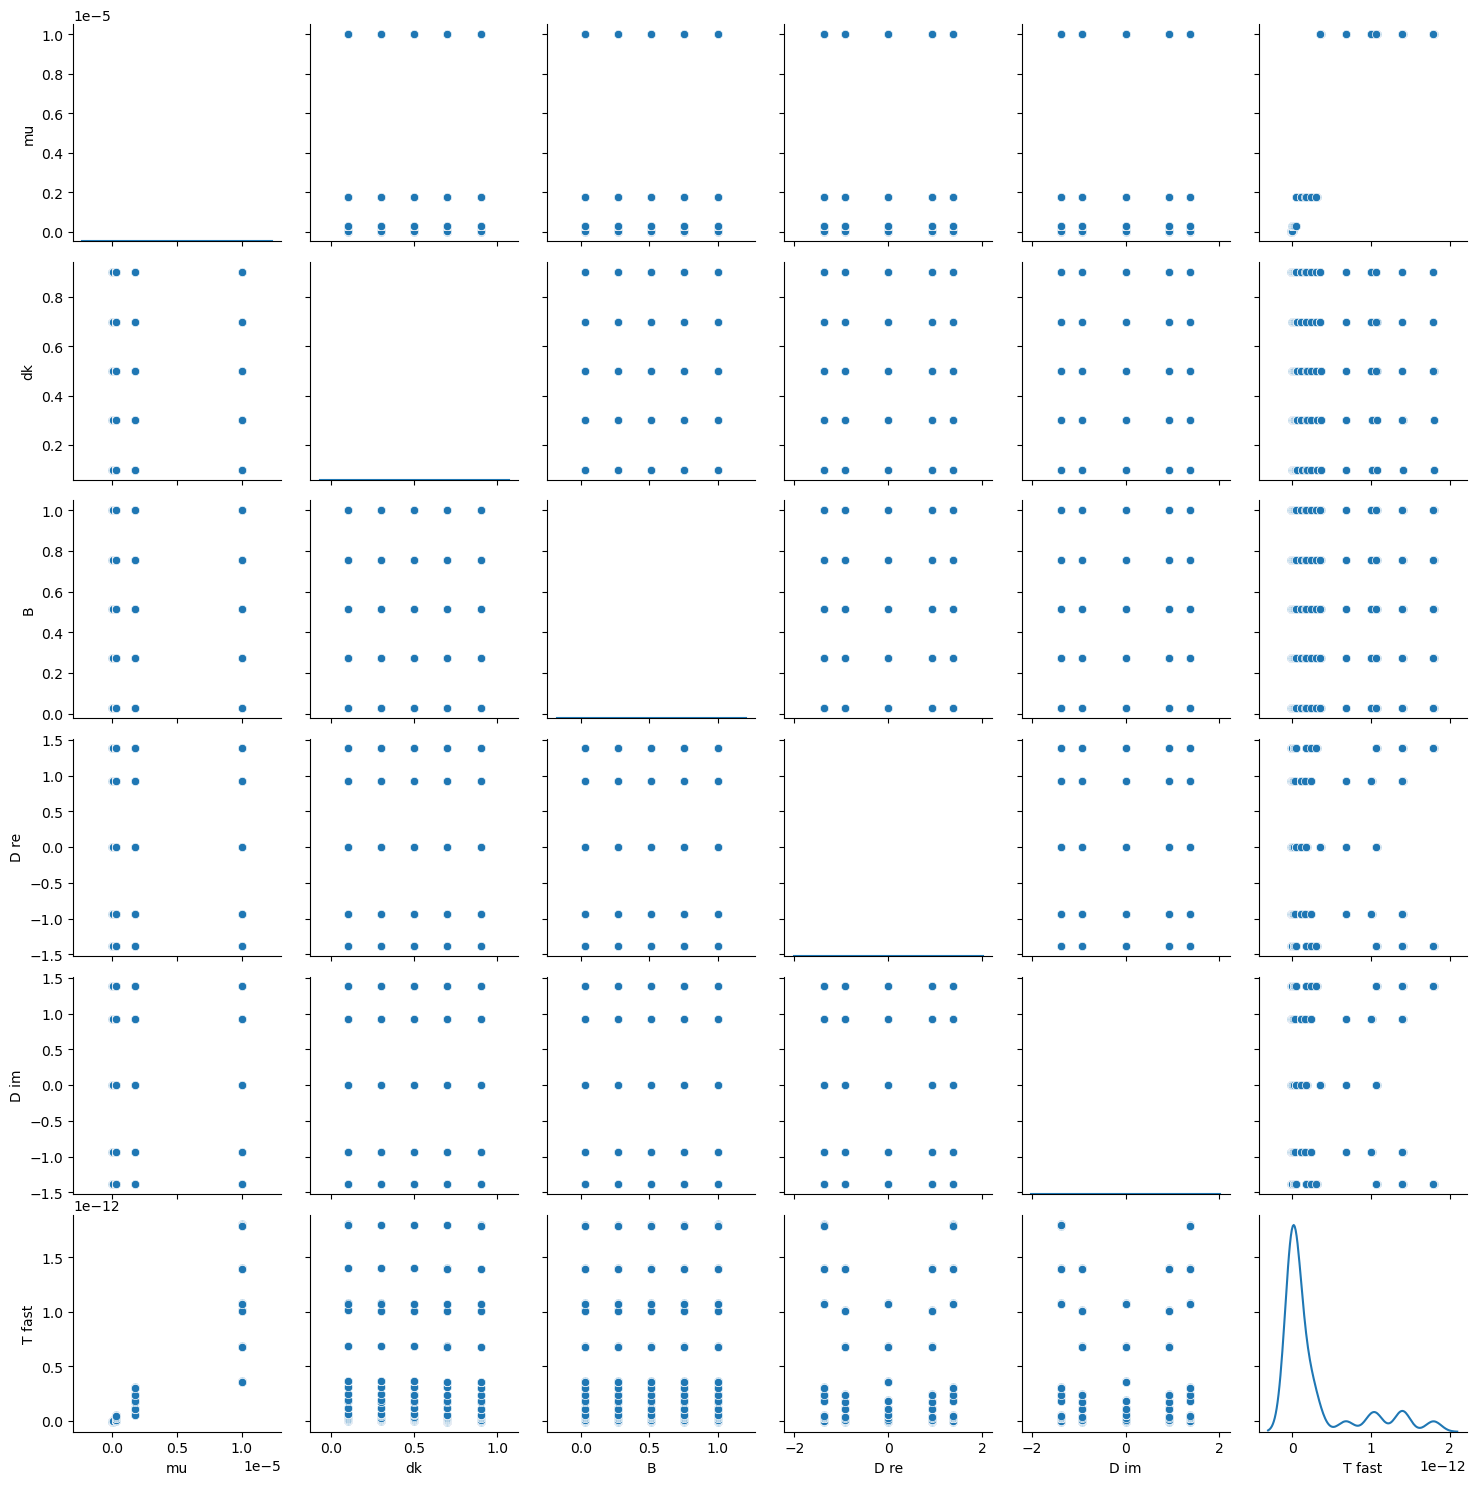

In [29]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

The expected pattern has appeared. I will need to look at how dk influences $\Psi^\prime_0$ dependences later. Now to get more data points.

# $\mu$ linear regression fitting

From my analysis of the triangle plots, the linear dependence of $t$ on $\mu$ is imediatly obvious. This linear scaling is then multiplied by some combination of the other variables. Therefore, I will start by finding the linear dependence of $t$ on $\mu$, with the intercept term remaining for further analysis. On the plot below, we can see that this linear dependence is the dominant term, with the intercept term being relatively close to zero.

Now, we need to find all the slopes and intercepts. We can then find the dependence of the slope on our other variables, with the intercept analysis dealt with later. The triangle plot analysis shows a dominant dependence of the slope on $a_1|A|^2 + a_2|\Psi^\prime_0|^2$.

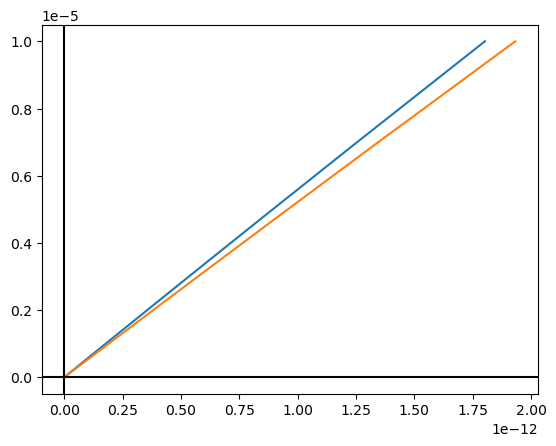

In [22]:
# for easy changing which two plots to use.
k1 = 3
k2 = 4
d1 = 0
d2 = 0
d3 = 1
d4 = 3

fig, ax = plt.subplots()
ax.plot(fot[:, k1,d1,d2]-t_new,nls)
ax.plot(fot[:, k2,d3,d4]-t_new,nls)
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Drawing lines:

\begin{equation}
y = a x + b
\end{equation}

\begin{equation}
y_1 - y_2 = a (x_1 - x_2)
\end{equation}

\begin{equation}
b = y - a x
\end{equation}

This was used to determine if there was a $\mu$ dependence on slope and intercept. For slope, there appears not to be.

In [333]:
# Storage arrays
slope = np.zeros((n_k,n_g,n_g))
intercept = np.zeros((n_k,n_g,n_g))

r = 1    # for finding the minimum r value

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            xx = nls
            yy = fot[:, i, j, k]

            sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

            slope[i,j,k]=sl
            intercept[i,j,k]=interc

            r = min(r, r2)
            #p = max(p, p2)
            #se = max(se, se2)

            print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0 0 0 1.2237545812028646e-07 2.6179139728674757e-10
0 0 1 1.1949857325630035e-07 2.617913985088784e-10
0 0 2 1.1443606114608955e-07 2.61791437085926e-10
0 0 3 1.0764070199446358e-07 2.6179149032773925e-10
0 0 4 9.968049105962005e-08 2.6179158474165946e-10
0 0 5 9.126859731405657e-08 2.6179162871140745e-10
0 0 6 8.311273154558008e-08 2.617916475999171e-10
0 0 7 7.591154926655136e-08 2.6179166464014847e-10
0 0 8 7.028308468582332e-08 2.6179166641706307e-10
0 0 9 6.669791464108725e-08 2.617917095245782e-10
0 0 10 6.54744009988165e-08 2.617916719599642e-10
0 0 11 6.670227879247053e-08 2.6179171344881283e-10
0 0 12 7.028276589454073e-08 2.617916848961212e-10
0 0 13 7.59089593388274e-08 2.61791690184306e-10
0 0 14 8.311069216536128e-08 2.6179165775170395e-10
0 0 15 9.126630718372136e-08 2.617916510372498e-10
0 0 16 9.968578350720656e-08 2.617915504375629e-10
0 0 17 1.0763677605467027e-07 2.617915071821309e-10
0 0 18 1.1443801236583947e-07 2.617914569712354e-10
0 0 19 1.1949721183221498e-07 2

The straight line is a very good fit. The intercept is very close to the expected $t_{new}$.

In [334]:
print(t_new-np.average(intercept), t_new-np.min(intercept), t_new-np.max(intercept))
print(1/np.average(intercept)-1/t_new)
#print(1/np.average(intercept)-1/t_1)

2.2150440808093696e-15 7.41961964810364e-15 4.684558562745638e-16
32320.004599571228


The intercept is around $5 \times 10^{-16}$ which is greater than the $10^{-16}$ or $10^{-17}$ level which I would like to reach. 

In [330]:
# 1% Error Tolerance

1/(1e-6/t_new) * t_new * 0.01

6.853534985605926e-16

In [335]:
# change in k (instead of t)

print((1/np.average(intercept)-1/t_new)/eelib.pi)

10287.77698554911


In [29]:
# But it doesn't appear related to the slow oscillation speed

print(np.sqrt(gridl.l_calc.M))

1987.4846828301415


In [30]:
# Range in slopes

np.max(slope), np.min(slope)

(4.559739510059996e-07, 9.192797457893529e-09)

Linear dependence of $\mu$ vs $t - t_0$

Result for intercept, add to $k$: $111873.9875407219$

* independent of $A_0$ and $\Psi^\prime$
* dependent on $\mu$ (I think), but may just be numerical error (can be checked with alternative ranges of $\mu$)
* if $\mu$ dependence is numerical error, the intercept itself is numerical error, and should be zero
* dependence on $k$, $dk$, and $B$ unknown
* Note that the intercept is $t_0$ (the period without $\mu$)

The greatest $p$ values are:
* R2: 0.9999976281979924 
* p: 1.3844923187575803e-22 
* se: 3.028692221455953e-10

Previous calculations show that slope is independent of $\mu$ while intercept depends on $\mu$. Indicates that there is a $\mu*f(A_0, \Psi^\prime_0)+ g(\mu, k, M)$ structure.

Slope dependent on $i$, j$$, $k$, but not on $l1$, $l2$. Intercept negative and becomes more negative for larger $l1$, $l2$. $-10^{-15}$ is smallest, compared to $10^{-13}$ for $dt$ or $10^{-10}$ for $t$. 

Plot this with respect to $\mu$, $\Psi^\prime$, $\Psi$

.... probably ignore this
grab the slope and average or maximum intercept
.... 


.... put in terms of $k^2$

In [37]:
# because I forgot how large I allowed this to get to.

np.abs(dgrid[j,k]/gridl.l_calc.k)

1.7442017094256994

# $A_0$ and $\Psi^\prime_0$ Regression

$\mu*f(a_0, \Psi^\prime_0)+ g(\mu, k, M)$

The slope here is approximately constant, while the intercept varies. The intercept doesn't go to zero.

$\mu*\left(|A_0|^2 + f(\Psi^\prime_0)\right)+ g(\mu, k, M)$

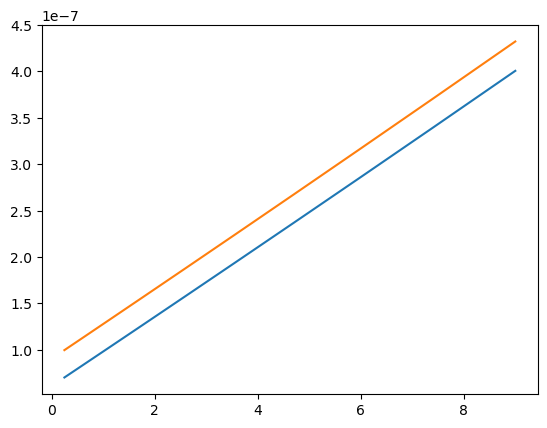

In [40]:
# parameters to easily change visible graphs
d1 = 0
d2 = 12
d3 = 3
d4 = 2

fig, ax = plt.subplots()
ax.plot(amp**2,slope[:,d1,d2])
ax.plot(amp**2,slope[:,d3,d4])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

#fig, ax = plt.subplots()
#ax.plot(amp**2,slope[:,3,2])
#plt.show()

#fig, ax = plt.subplots()
#ax.plot(fot[:, 4,1,1]-t_new,nls)
#plt.show()

In [41]:
np.shape(slope)

(10, 21, 21)

In [42]:
slope2 = np.zeros((n_g,n_g))
intercept2 = np.zeros((n_g,n_g))
r = 1

for j in range(n_g):
    for k in range(n_g):
        xx = amp**2
        yy = slope[:,j,k]

        sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

        slope2[j,k]=sl
        intercept2[j,k]=interc

        r = min(r, r2)

        print(j, k, slope2[j,k], intercept2[j,k], r2)

print(np.average(slope2), r)

0 0 3.8091966309274166e-08 1.1221127283019272e-07 0.9999887944142256
0 1 3.8070373653053236e-08 1.0933809627517779e-07 0.9999887784027609
0 2 3.803332053858246e-08 1.0428616507310998e-07 0.9999888417157213
0 3 3.798297633778213e-08 9.750046511606798e-08 0.9999888418558087
0 4 3.792398013173892e-08 8.956558606846316e-08 0.9999890024239707
0 5 3.786195681007659e-08 8.116832313693239e-08 0.9999890087115454
0 6 3.780160243043775e-08 7.303056021834967e-08 0.999989092657886
0 7 3.7749075197636646e-08 6.584533909546652e-08 0.9999891787924496
0 8 3.770716846787657e-08 6.023000927681639e-08 0.9999892323329664
0 9 3.7681185262270485e-08 5.665625772005843e-08 0.9999892584288691
0 10 3.7672964355537604e-08 5.543198547199078e-08 0.9999892320797983
0 11 3.768191977070415e-08 5.665713035652863e-08 0.9999892728896138
0 12 3.770780448774802e-08 6.022922199418932e-08 0.9999892455657081
0 13 3.774930458202902e-08 6.584550751705541e-08 0.9999891458193865
0 14 3.780262951192582e-08 7.302976245683949e-08 0.

Slope is almost independent of $\Psi^\prime$, intercept is not.

Slope: 3.698062210078747e-08 

r: 0.9999992783744597 

p: 1.186383953629946e-24 

se:1.5713552843315777e-11

Source of slope in units???

In [340]:
# error in slope

slope_A = np.average(slope2)
(np.std(slope2))/slope_A

0.0047722971206014195

In [44]:
dlist = np.real(dgrid[1])

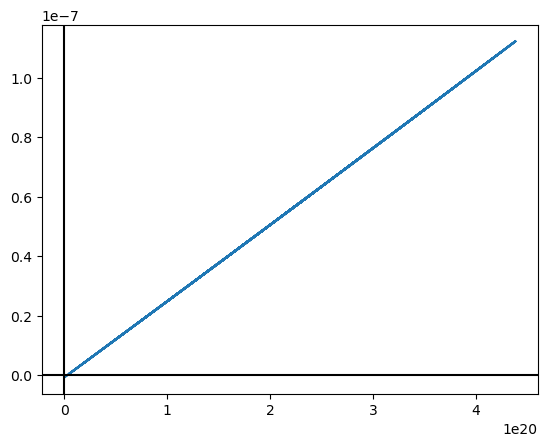

In [48]:
# |psi'_0|^2 vs f(psi'_0)

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,intercept2.flatten())
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Already not so clear. Error is visible. Intercept not zero.
The zig-zag and intercept can be due to a splitting of the real and imaginary components of the derivative. Perhaps I should separate them already.

Lets split the real and imaginary components.

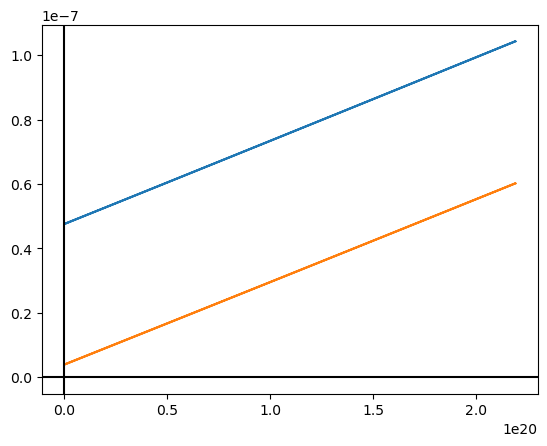

In [54]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.real(dgrid[2])**2,intercept2[d1])
ax.plot(np.real(dgrid[2])**2,intercept2[d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

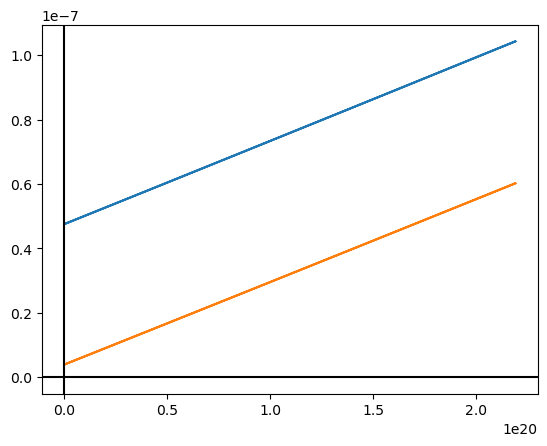

In [53]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,2])**2,intercept2[:,d1])
ax.plot(np.imag(dgrid[:,2])**2,intercept2[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

The zig-zag has not been removed. I will try to fit these two components, and see what remains. The zig-zag may be an artifact of plotting, despite the fact that I didn't see it before. My assumption is a  $\frac{|psi^\prime|^2}{k^2}$ term with the same slope as $A_0$, an additional $\Im (\Psi^\prime)$ term, and non-linear $\mu$ terms.

And there may be an error due to $k$ here being $k_{new}$, not $k_0$. Perhaps fit with a recurrsive formula; one correction to $k$ should be enough here. I think that there is a term, non-linear in $\mu$, which produces a stronger result.

In [57]:
# full dataset regression 

xx = np.abs(dgrid.flatten())**2
yy = intercept2.flatten()

sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

print(sl/t_new**2*eelib.pi**2, interc, r2)

3.712978769853231e-08 -9.987401301876449e-10 0.9999953746219353


R values still good. Slope close to $A_0$ slope, as it should be, but closer if -intercept is added. Assume no intercept and $A_0$ slope is correct for $\left(\frac{\Psi^\prime_0}{k}\right)^2$ I still don't know what the $A_0$ slope comes from. I need to check my constants. 

Separated regression

In [59]:
slope3 = []
intercept3 = []

for i in range(n_g):
    xx = np.real(dgrid[i])**2
    yy = intercept2[i]

    sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)
    slope3.append(sl)
    intercept3.append(interc)

    print(sl/t_new**2*eelib.pi**2, interc, r2)

3.732643198974281e-08 5.539371172408226e-08 0.999999067138905
3.730623326560941e-08 5.254971716447249e-08 0.9999990427683406
3.7271129460080307e-08 4.755168609763967e-08 0.9999990630442146
3.722316448795392e-08 4.083572574681899e-08 0.9999990587267044
3.7167630772112334e-08 3.298177271829799e-08 0.9999990767351721
3.7110630854684495e-08 2.466871472796679e-08 0.9999990794510734
3.7053874803067386e-08 1.661254798010198e-08 0.9999990970659822
3.7002332516488454e-08 9.501983866907701e-09 0.9999991022380808
3.696479378750576e-08 3.939920723714455e-09 0.9999991089687137
3.6939311702801825e-08 4.0302458624193e-10 0.9999991017932012
3.6930238577824506e-08 -8.119069657972706e-10 0.999999096685122
3.693910407722859e-08 3.968203502839496e-10 0.999999102284271
3.6964929045018684e-08 3.927038332662623e-09 0.9999991070347272
3.700247505247405e-08 9.483321544706612e-09 0.9999990943753956
3.705358336878587e-08 1.6588500597680685e-08 0.9999991057371032
3.711061545221384e-08 2.463949613053577e-08 0.9999

Visible $\Im(\Psi^\prime)$ dependence on slope at around the % level.

In [60]:
slope4 = []
intercept4 = []

for i in range(n_g):
    xx = np.imag(dgrid[:,i])**2
    yy = intercept2[:,i]

    sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)
    slope4.append(sl)
    intercept4.append(interc)

    print(sl/t_new**2*eelib.pi**2, interc, r2)

3.733337284365883e-08 5.536180326986586e-08 0.9999987603730586
3.731297913367989e-08 5.251966946324101e-08 0.9999987584310768
3.727722369796132e-08 4.752411017094329e-08 0.9999987925360999
3.722953871374849e-08 4.0810097447612087e-08 0.9999987682910907
3.717345890253517e-08 3.295999262991651e-08 0.9999987846288496
3.7115613806993335e-08 2.465091478921866e-08 0.9999987717736665
3.705944063976051e-08 1.6598251820592752e-08 0.9999987509375527
3.700987676603309e-08 9.49018393346848e-09 0.9999988126283017
3.697057397575003e-08 3.933423590438999e-09 0.9999987742954156
3.6945366585844384e-08 3.9919232431790155e-10 0.999998782716212
3.693762299294973e-08 -8.130961584956334e-10 0.99999879296147
3.6946515829238374e-08 3.984903465642338e-10 0.9999987694877658
3.6970265568260205e-08 3.9334813939609404e-09 0.9999987736284444
3.70085464189635e-08 9.490625749434378e-09 0.9999987788667516
3.70590264695931e-08 1.6598409259333284e-08 0.9999987580826154
3.7114990821441185e-08 2.4650729542757358e-08 0.999

Again, dependence on $\Re(\Psi^\prime)$ visible at around the % level. 

In [71]:
slope_0_d = np.min([np.min(slope3), np.min(slope4)])

In [61]:
slope_A

3.772390428468754e-08

In [64]:
slope_0_d/t_new**2*eelib.pi**2

3.6933930785387116e-08

Correction to $k$ on order of %. Lets try fitting not $\Psi^\prime$ but $\frac{\Psi^\prime}{k}$. 

k = eelib.pi/fot[ii,jj,kk,ll]?

In [69]:
xx = []
yy = []
for ii in range(n_m):
    for jj in range(n_k):
        for kk in range(n_g):
            for ll in range(n_g):
                xx.append(abs(dgrid[kk,ll]*fot[ii,jj,kk,ll]/eelib.pi)**2)
                yy.append((fot[ii,jj,kk,ll]-t_new)/nls[ii]-slope_A*amp[jj]**2)

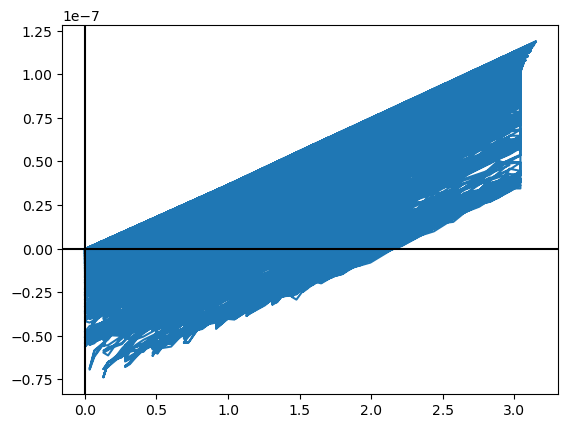

In [70]:
fig, ax = plt.subplots()
ax.plot(np.abs(xx),yy)
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

... I am not quite sure what is visible here. However, linear dependence is obvious. $k_0$ works better. Perhaps I can just subtract the $k_0$ term and work out the $O(3)$ terms afterwords. 

# Remainder and Linear Term

We are down to about $10^{-2}$ times our original correction to $t$.

In [77]:
np.shape(intercept2)

(21, 21)

In [78]:
remainder2 = intercept2
remainder3 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder3[i,j] = remainder2[i,j] - slope_0_d*np.abs(dgrid[i,j])**2

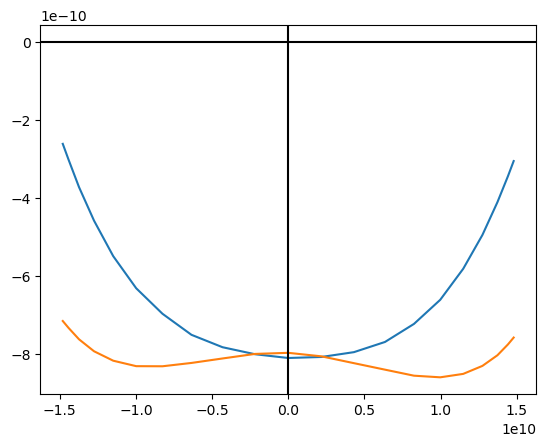

In [91]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1]),remainder3[:,d1])
ax.plot(np.imag(dgrid[:,d2]),remainder3[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

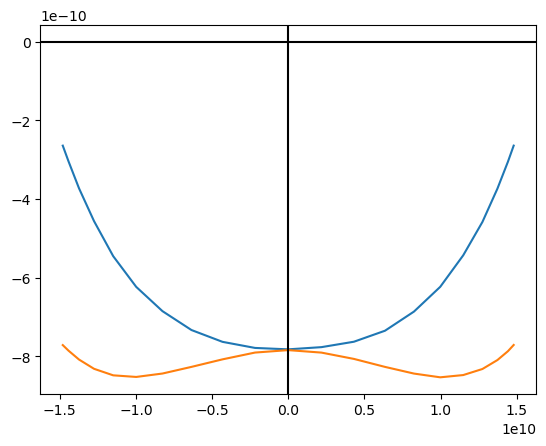

In [89]:
d1 = 2
d2 = 11

fig, ax = plt.subplots()
ax.plot(np.real(dgrid[d1]),remainder3[d1])
ax.plot(np.real(dgrid[d2]),remainder3[d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Fourth-order term. Of course ... I think the fourth order term will be needed, but the sixth-order will not. Note that in the imaginary there is also a linear component -- orders of $\Im(\Psi^\prime)$, not just $|\Psi^\prime| ^ 2$.

Linear regression to a function of the form 
\begin{equation}
a_1 \Re(\Psi^\prime) ^4 + a_2 \Re(\Psi^\prime) ^2 \Im(\Psi^\prime) ^2 + a_3 \Im(\Psi^\prime) ^4 + a_4 \Re(\Psi^\prime)^2 + a_5 \Im(\Psi^\prime)^2 +a_6 \Im (\Psi^\prime) + a_7
\end{equation}

Perhaps there are $A_0$ coupling terms as well.

Expected terms come from this equation:

\begin{equation}
|a|^2+|b|^2 = \frac{|\Psi^\prime_0|^2}{2 k^2} + \frac{|\Psi_0|^2}{2} \left(1+\frac{M^2}{k^2}\right) - \Psi_0 \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

And without the $\frac{M^2}{k^2}$ term:
\begin{equation}
|a|^2+|b|^2 = \frac{|\Psi^\prime_0|^2}{2 k^2} + \frac{|\Psi_0|^2}{2} - \Psi_0 \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

In [127]:
remainder4 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder4[i,j] = remainder2[i,j] - slope_0_d*np.abs(dgrid[i,j])**2+np.sqrt(2)*slope_0_d*np.imag(dgrid[i,j])*gridl.l_calc.M

In [104]:
slope_0_d/t_new**2*eelib.pi**2

3.6930238577824506e-08

In [103]:
slope_A

3.772390428468754e-08

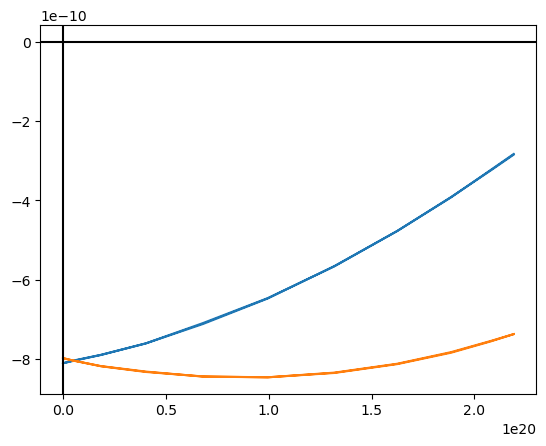

In [128]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1])**2,remainder4[:,d1])
ax.plot(np.imag(dgrid[:,d2])**2,remainder4[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

I like $\sqrt{2}$ here for the linear term. I still see a slight separation, but it is good. I wonder if this is actually ave $(A_0)$. NO.. Perhaps unrelated to $A_0$.
I can see if a better estimate for the slope gets closer to the correct line.

In [130]:
np.sqrt(np.average(amp))

1.3228756555322954

Our $4^{th}$ power terms are then here: 
\begin{equation}
\frac{|\Psi^\prime_0|^4}{4 k^4}, \quad 
\frac{|\Psi^\prime_0|^2 |\Psi_0|^2}{2 k^2} \left(1+\frac{M^2}{k^2}\right), \quad 
\frac{M \Psi_0 |\Psi^\prime_0|^2  \Im(\Psi^\prime_0)}{k^4}, \quad
\frac{|\Psi_0|^4}{4} \left(1+\frac{M^2}{k^2}\right)^2, \quad 
\Psi_0^3 \left(1+\frac{M^2}{k^2}\right) \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}, \quad 
\Psi_0^2 \frac{M^2}{k^2} \frac{\Im(\Psi^\prime_0)^2}{k^2}
\end{equation}

Without $\frac{M^2}{k^2}$:
\begin{equation}
\frac{|\Psi^\prime_0|^4}{4 k^4}, \quad 
\frac{|\Psi^\prime_0|^2 |\Psi_0|^2}{2 k^2} , \quad 
\frac{M \Psi_0 |\Psi^\prime_0|^2  \Im(\Psi^\prime_0)}{k^4}, \quad
\frac{|\Psi_0|^4}{4} , \quad 
\Psi_0^3  \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

# Quartic Terms

In [132]:
np.shape(remainder4)

(21, 21)

Regression with linear, quadratic, and quartic terms.

In [136]:
X = np.zeros((n_g**2,6))
y = np.zeros((n_g**2))

for ii in range(n_g):
    for jj in range(n_g):
        X[ii*n_g + jj] = np.array([np.real(dgrid[ii,jj])**4, np.real(dgrid[ii,jj])**2*np.imag(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**4, 
                                   np.real(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**2,np.imag(dgrid[ii,jj])])
        y[ii*n_g + jj] = remainder4[ii,jj]

In [137]:
reg = LinearRegression().fit(X, y)

reg.score(X, y)

0.9639889511571801

In [138]:
reg.coef_

array([ 1.50043429e-51,  1.01422164e-50,  1.68384418e-51,  8.16975837e-71,
        7.67955416e-72, -5.30897681e-98])

No evidence for linear and quadratic terms.

In [140]:
slope_0_d

2.5644663335438e-28

In [141]:
X = np.zeros((n_g**2,3))
y = np.zeros((n_g**2))

for ii in range(n_g):
    for jj in range(n_g):
        X[ii*n_g + jj] = np.array([np.real(dgrid[ii,jj])**4, np.real(dgrid[ii,jj])**2*np.imag(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**4])
        y[ii*n_g + jj] = remainder4[ii,jj]

In [142]:
reg = LinearRegression().fit(X, y)

reg.score(X, y)

0.9639889511571801

In [143]:
reg.coef_

array([1.50043429e-51, 1.01422164e-50, 1.68384418e-51])

In [144]:
reg.intercept_

-8.740934838261812e-10

Linear and quadratic terms are already removed. There may be a correction with $A_0$ terms or non-linear $\mu$ terms. Here we have only quartic terms left.

In [146]:
slope_4_d = reg.coef_
print(slope_4_d/t_new**4*eelib.pi**4)

[3.11162464e-11 2.10330908e-10 3.49198302e-11]


In [148]:
remainder5 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder5[i,j] = remainder4[i,j] - np.matmul(slope_4_d,np.array([np.real(dgrid[i,j])**4, np.real(dgrid[i,j])**2*np.imag(dgrid[i,j])**2, np.imag(dgrid[i,j])**4]).T)

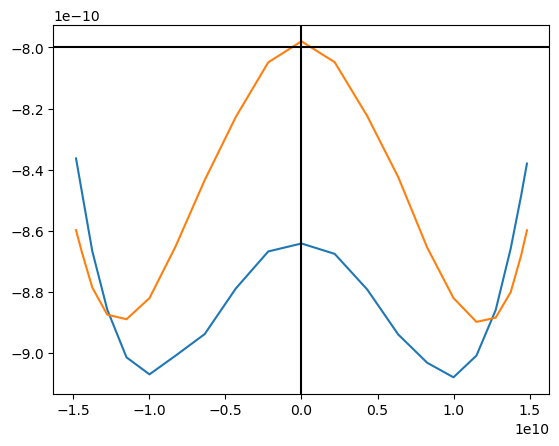

In [154]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1]),remainder5[:,d1])
ax.plot(np.imag(dgrid[:,d2]),remainder5[:,d2])
plt.axline((0,-8e-10), (1e-12,-8e-10), color='k')
plt.axline((0,-8e-10), (0,-8.5e-10), color='k')
plt.show()

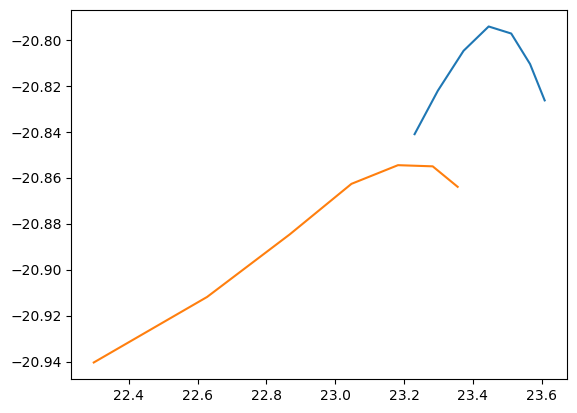

In [178]:
d1 = 4
d2 = 11

fig, ax = plt.subplots()
ax.plot(np.log(abs(dgrid[d1, 12:19])),np.log(-remainder5[d1, 12:19]))
ax.plot(np.log(abs(dgrid[d2, 12:19])),np.log(-remainder5[d2, 12:19]))
#plt.axline((0,-8e-10), (1e-12,-8e-10), color='k')
#plt.axline((0,-8e-10), (0,-8.5e-10), color='k')
plt.show()

Non-linear, not a power law (although may just be an intercept issue), ... I think the rest either requires examining relationships with other terms or will just remain. I don't know if it is required to remove the other terms. I will need to check how close my error is to my tolerance.

# Calculation of Remaining Terms

Lets calculate the difference between fot and our calculated results first. Then we can see if we can find linear fits to any other remaining terms, which can then be added to our calculated results. 

In [215]:
f_dt_A2 = np.zeros((n_m, n_k, n_g, n_g))
g_fun = np.zeros((n_m, n_k, n_g, n_g))
for nn in range(n_m): 
    for ii in range(n_k):
        for jj in range(n_g):
            for kk in range(n_g):
                # mu = 0 period
                g_fun[nn,ii,jj,kk] = fot[nn,ii,jj,kk] - t_new 
                # A_0 quadratic term
                #g_fun[nn,ii,jj,kk] = g_fun[nn,ii,jj,kk] / nls[ii]
                g_fun[nn,ii,jj,kk] -= slope_A*amp[ii]**2 *nls[nn]
                # linear and quadratic terms for psi '
                g_fun[nn,ii,jj,kk] -= slope_0_d*np.abs(dgrid[jj,kk])**2 *nls[nn] - np.sqrt(2)*slope_0_d*np.imag(dgrid[jj,kk])*gridl.l_calc.M * nls[nn]
                # quartic psi ' terms
                g_fun[nn,ii,jj,kk] -= nls[nn]*np.matmul(slope_4_d,np.array([np.real(dgrid[i,j])**4, 
                                                                    np.real(dgrid[i,j])**2*np.imag(dgrid[i,j])**2, 
                                                                    np.imag(dgrid[i,j])**4]).T)


In [216]:
np.max(g_fun), np.min(g_fun)

(5.810924358574203e-14, -3.541950100066034e-14)

I need to find slope dependencies on M and k ....

Redoing our array and dataframe.

In [217]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k* n_m * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = g_fun[imu, ia, idr, idi]

88200
True


# Triangle Plots $2^{nd}$ Time

In [ ]:

dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "D T fast"])

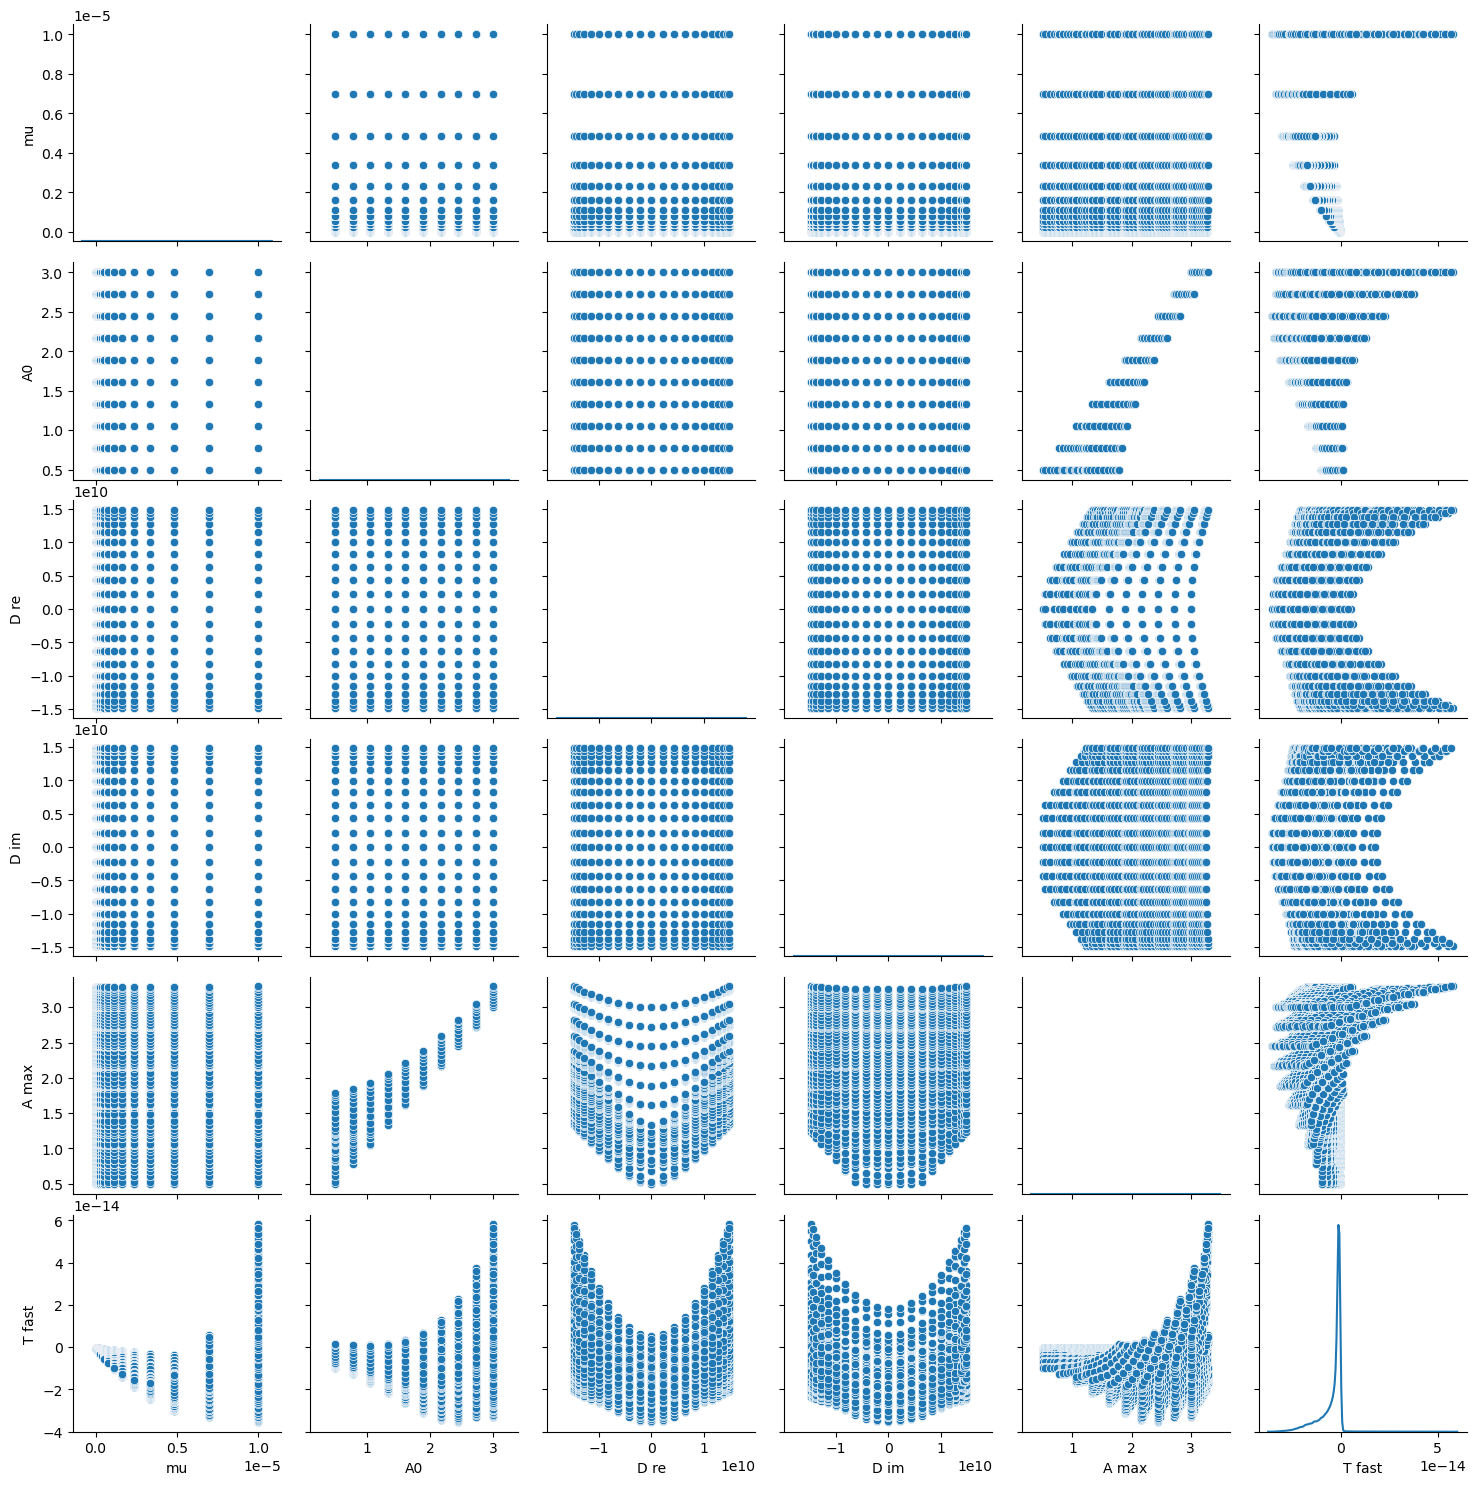

In [ ]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

In [ ]:
#t_0 = eelib.pi/eelib.kFAu
#npaf[:,-1]= npaf[:,-1]-t_new
#npaf[:,-1]= npaf[:,-1] / npaf[:,0]
#npaf[:,0]=np.power(npaf[:,0], 1/4)
npaf[:,1]=np.power(npaf[:,1],2)
#npaf[:,2]=np.power(npaf[:,2],2)
#npaf[:,3]=np.power(npaf[:,3],2)

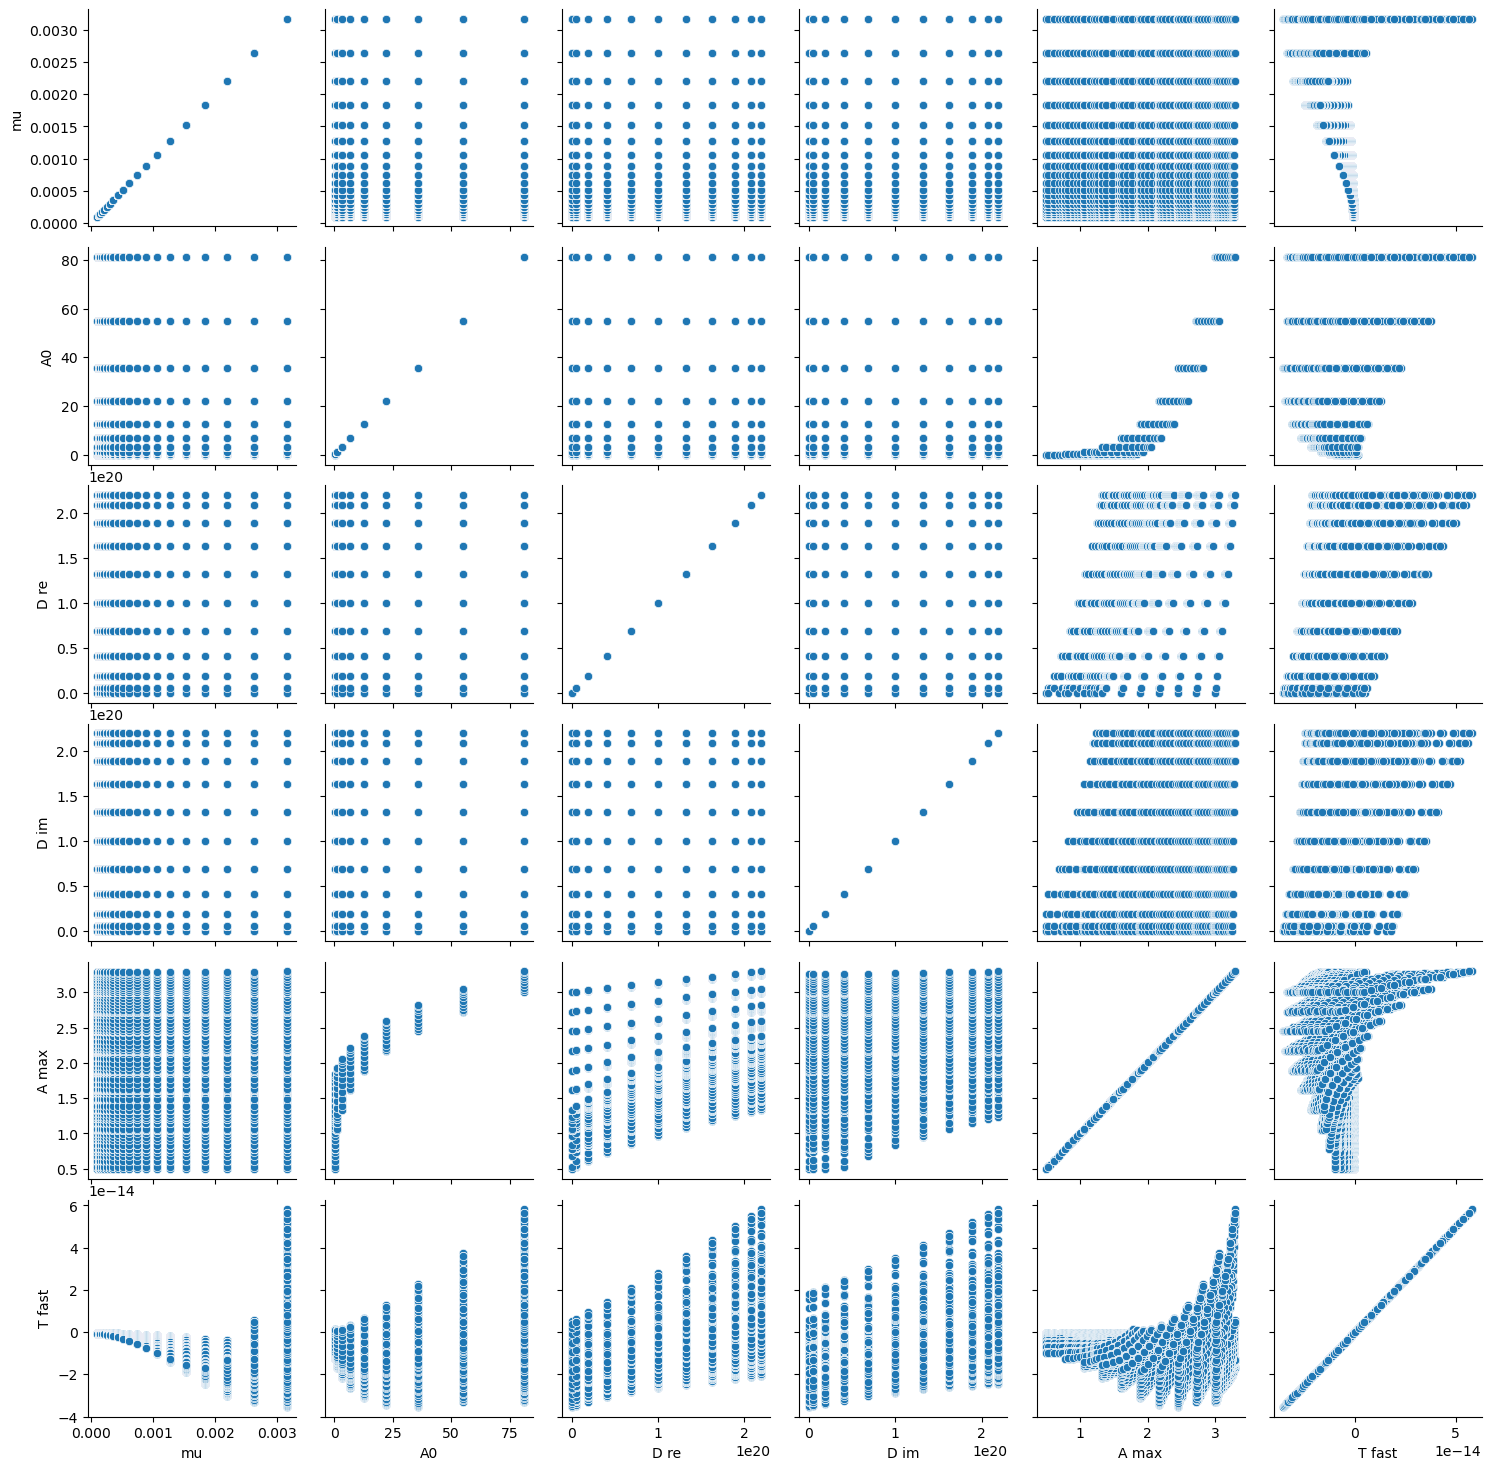

In [ ]:
#dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

g = sns.PairGrid(dfa)
g.map(sns.scatterplot)

$\mu$ and $\sqrt{\mu}$ terms, all multiplied by one or the other

There is an $A^4$ term in here.

$(\Psi^\prime)^2$ terms are dominant, but also real and imag are independent, and there is something else.

# Separation of remaining linear and quadratic terms for mu

I have here collapsed the outputs in this section since it is rather long and was difficult to search. 

This is our remainder array.

Here is our remaining $\mu$ dependence.

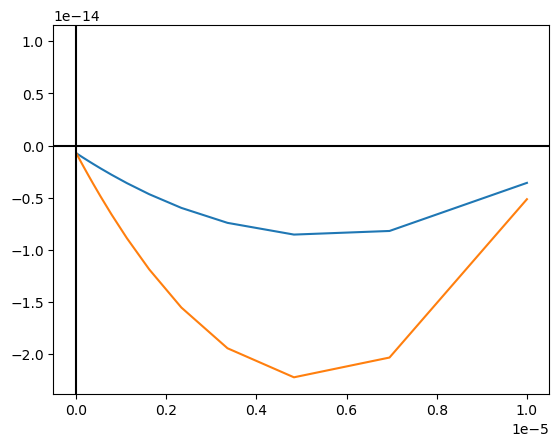

In [259]:
k1 = 3
k2 = 8
d1 = 0
d2 = 17
d3 = 1
d4 = 8

fig, ax = plt.subplots()
ax.plot(nls,g_fun[:, k1,d1,d2])
ax.plot(nls,g_fun[:, k2,d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

And our largest error.

In [254]:
np.min(g_fun[0,:,:,:])

-8.450346062635081e-16

Separating out constant, $\mu$, and $\mu^2$ terms.

In [348]:
slope = np.zeros((n_k,n_g,n_g,2))
intercept = np.zeros((n_k,n_g,n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
            X = np.array([nls, np.power(nls,2)]).T
            y = g_fun[:, i, j, k]
            #y = nls

            reg = LinearRegression().fit(X, y)

            slope[i,j,k]=reg.coef_
            intercept[i,j,k]=reg.intercept_

            r2 = reg.score(X, y)
            #p = max(p, p2)
            #se = max(se, se2)
            r = min(r, r2)

            print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0 0 0 [-1.45683028e-09  1.63460826e-04] -4.761818961515713e-16
0 0 1 [-1.43933737e-09  1.55713458e-04] -5.079859515326593e-16
0 0 2 [-1.41181147e-09  1.42086336e-04] -5.274998372563617e-16
0 0 3 [-1.37004740e-09  1.25079263e-04] -5.467573184073367e-16
0 0 4 [-1.33887475e-09  1.06795886e-04] -5.302834395130584e-16
0 0 5 [-1.29494655e-09  8.91951897e-05] -5.613435358924241e-16
0 0 6 [-1.25143721e-09  7.31384886e-05] -6.1090298998045e-16
0 0 7 [-1.21907913e-09  6.05931461e-05] -6.473421841403593e-16
0 0 8 [-1.19058359e-09  5.13821421e-05] -6.848307738311266e-16
0 0 9 [-1.18729221e-09  4.69956524e-05] -6.604223850507113e-16
0 0 10 [-1.16673138e-09  4.40018481e-05] -7.107492597420187e-16
0 0 11 [-1.17317864e-09  4.58491565e-05] -6.613855370868295e-16
0 0 12 [-1.19335306e-09  5.16703332e-05] -6.651231882396084e-16
0 0 13 [-1.21809306e-09  6.01726218e-05] -6.235906756976116e-16
0 0 14 [-1.25478264e-09  7.32920756e-05] -6.000964784008688e-16
0 0 15 [-1.29311225e-09  8.87101713e-05] -5.41085274

This works beautifully. The only issue is the intercept term. I should solve for this as a function of my other parameters, but ... 

Slope 0 is the linear term, slope 1 is the quadratic term, intercept is the constant term. Lets label them more obviously.

In [261]:
slope_lin = slope[:,:,:,0]
slope_quad = slope[:,:,:,1]

**Linear Term**

First, the linear term, for the remaining power which was not properly attributed before.

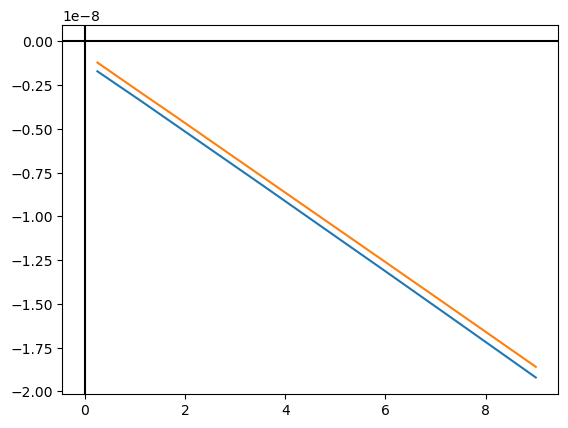

In [342]:
d1 = 0
d2 = 0
d3 = 13
d4 = 12

fig, ax = plt.subplots()
ax.plot(amp**2,slope_lin[:, d1,d2]-1.e-9*amp**2)
ax.plot(amp**2,slope_lin[:, d3,d4]-1.e-9*amp**2)
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

This appears to be an $A_0^2$ component ... Coupling is minor if it exists. I think our slope_A value was too high.

In [442]:
slopel2a = np.zeros((n_g,n_g))
interceptl2a = np.zeros((n_g,n_g))
r = 1.1    # for finding the minimum r value


for j in range(n_g):
    for k in range(n_g):
        #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
        X = np.array([np.power(amp,2)]).T
        y = slope_lin[:, j, k]
        #y = nls

        reg = LinearRegression().fit(X, y)

        slopel2a[j,k]=reg.coef_[0]
        interceptl2a[j,k]=reg.intercept_

        r2 = reg.score(X, y)
        #p = max(p, p2)
        #se = max(se, se2)
        r = min(r, r2)

        print(j, k, slopel2a[j,k], interceptl2a[j,k])

print(r)

0 0 -9.997337152573342e-10 -1.1646478212399412e-09
0 1 -9.983477235873954e-10 -1.1538673391645563e-09
0 2 -9.95667789794703e-10 -1.1334477910152074e-09
0 3 -9.93745565193367e-10 -1.096952069886636e-09
0 4 -9.913129029341642e-10 -1.0593691045767154e-09
0 5 -9.88660745825649e-10 -1.0196945357024478e-09
0 6 -9.86713745652056e-10 -9.790422660091178e-10
0 7 -9.835322362389804e-10 -9.496622800938933e-10
0 8 -9.832917353234359e-10 -9.204710812576033e-10
0 9 -9.809578605386427e-10 -9.091295330161957e-10
0 10 -9.808620666284056e-10 -8.973284046885922e-10
0 11 -9.81679845657833e-10 -9.030944709348025e-10
0 12 -9.825518438348972e-10 -9.228555633407827e-10
0 13 -9.838013581465975e-10 -9.454488150670108e-10
0 14 -9.848361635949463e-10 -9.819389611217334e-10
0 15 -9.881054382736556e-10 -1.0202748106244613e-09
0 16 -9.90493829775843e-10 -1.0612430926925972e-09
0 17 -9.945416218565094e-10 -1.0936973243815138e-09
0 18 -9.96390967996107e-10 -1.1281045089860096e-09
0 19 -9.974995975549883e-10 -1.15530860

Putting a term linear in $A$ here appears not to be helpful. R value is quite good.

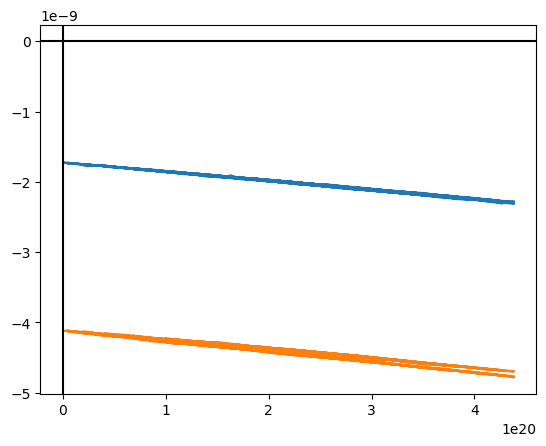

In [268]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,slope_lin[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,slope_lin[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

Also parallel. There is a separation, indicating abs doesn't give all the dependence. Perhaps a linear term, or separation of real and imaginary components? Separation has an $A_0$ dependence.

Terms:

\begin{equation}
\mu |A_0|^2, \quad \mu \Im(\Psi_0^\prime)^2, \quad \mu \Re(\Psi_0^\prime)^2, \quad \mu A_0 \Im(\Psi_0^\prime), ...
\end{equation}

In [443]:
slopel2d = np.zeros((n_k,3))
interceptl2d = np.zeros((n_k))
r = 1.1    # for finding the minimum r value


for i in range(n_k):
    #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
    X = np.array([np.imag(dgrid.flatten()), np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
    y = slope_lin[i, :, :].flatten()
    #y = nls

    reg = LinearRegression().fit(X, y)

    slopel2d[i]=reg.coef_
    interceptl2d[i]=reg.intercept_

    r2 = reg.score(X, y)
    #p = max(p, p2)
    #se = max(se, se2)
    r = min(r, r2)

    print(i, slopel2d[i], interceptl2d[i])

print(r)

0 [ 4.37045815e-22 -1.27766533e-30 -1.28550431e-30] -8.805989968740208e-10
1 [-1.14011615e-22 -1.28129449e-30 -1.29445683e-30] -1.226186181178231e-09
2 [-6.74527454e-22 -1.29800500e-30 -1.30668599e-30] -1.7222930687500013e-09
3 [-1.22190044e-21 -1.32874513e-30 -1.33721915e-30] -2.3664343638217383e-09
4 [-1.82039775e-21 -1.36158920e-30 -1.35445659e-30] -3.164714058572118e-09
5 [-2.38421710e-21 -1.41711075e-30 -1.40617746e-30] -4.111466823575287e-09
6 [-2.90611892e-21 -1.49164974e-30 -1.45906356e-30] -5.2118550144829026e-09
7 [-3.47595072e-21 -1.58636986e-30 -1.52576556e-30] -6.46825643410712e-09
8 [-4.05326200e-21 -1.73703560e-30 -1.61794801e-30] -7.881125791952358e-09
9 [-4.58077793e-21 -1.90970511e-30 -1.73245288e-30] -9.457681173151243e-09
0.9979704099329143


R value is not as good for the derivitive terms, but still good. Best results have $\Im(\Psi^\prime_0)$, $\Im(\Psi^\prime_0)^2$, and $\Re(\Psi^\prime_0)^2$ components. I will try this regression again on the version with the $A$ components separated.

In [445]:
slopel2a[1]

array([-9.98719269e-10, -9.97511460e-10, -9.96967598e-10, -9.93178881e-10,
       -9.90415689e-10, -9.88811344e-10, -9.86466638e-10, -9.83954741e-10,
       -9.82880680e-10, -9.82140105e-10, -9.80525867e-10, -9.81861228e-10,
       -9.82541007e-10, -9.82850576e-10, -9.84887565e-10, -9.87059634e-10,
       -9.90465589e-10, -9.92987020e-10, -9.96780244e-10, -9.97120103e-10,
       -9.98341834e-10])

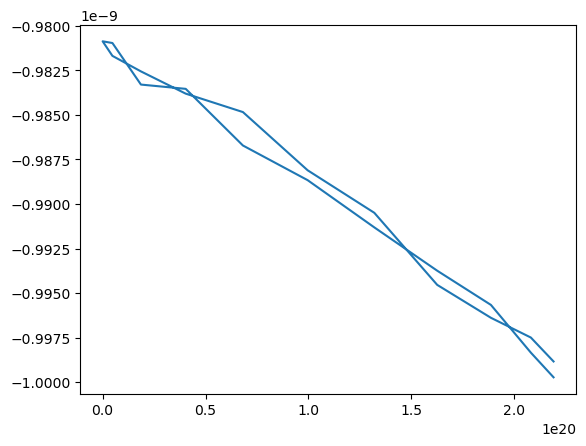

In [451]:
fig, ax = plt.subplots()
ax.plot(dlist**2,slopel2a[0,:])
#ax.plot(amp**2,slope_lin[:, d3,d4])1

In [461]:
#slopel3a = np.zeros((3))
#interceptl3a = np.zeros((n_g,n_g))
#r = 1.1    # for finding the minimum r value


#for j in range(n_g):
#    for k in range(n_g):
        #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
X = np.array([np.imag(dgrid.flatten()), np.imag(dgrid.flatten())**2, np.real(dgrid.flatten())**2]).T
y = slopel2a.flatten()
        #y = nls

reg = LinearRegression().fit(X, y)

slopel3a=reg.coef_
interceptl3a=reg.intercept_

r = reg.score(X, y)

print(slopel3a, interceptl3a)

print(r)

[-5.53135829e-22 -4.99113527e-32 -7.02401256e-32] -9.791764394287865e-10
0.9908299744844478


$\mu A^2$ component, without $\Psi^\prime_0$ components.

In [455]:
slope_A + interceptl3a

3.674472784525875e-08

Saving our $\mu A^2$ constant terms. Remember -- $k$ and $M$ are held constant here, so there may be dependence on them.

In [457]:
consts = {}
consts["muA2"] = slope_A + interceptl3a
consts["muA2I"] = slopel3a[0]
consts["muA2I2"] = slopel3a[1]
consts["muA2R2"] = slopel3a[2]

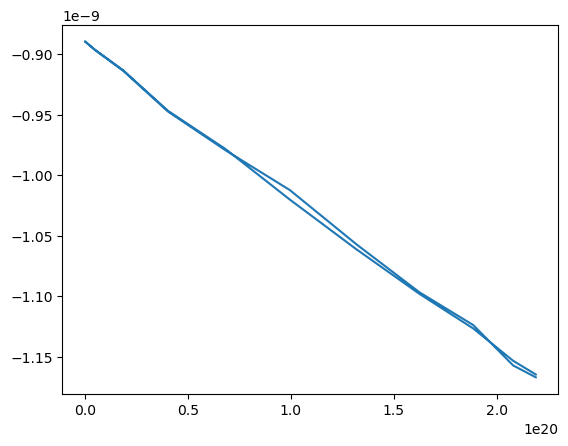

In [459]:
fig, ax = plt.subplots()
ax.plot(dlist**2,interceptl2a[:,0])
#ax.plot(amp**2,slope_lin[:, d3,d4])

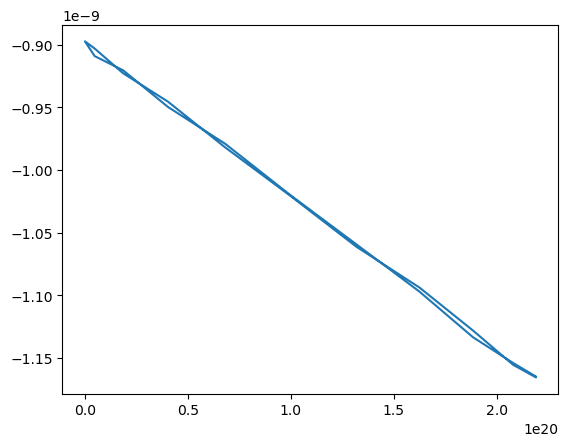

In [460]:
fig, ax = plt.subplots()
ax.plot(dlist**2,interceptl2a[0,:])
#ax.plot(amp**2,slope_lin[:, d3,d4])

Now to get the intercept terms of the linear $\mu$ term with relationship to $A^2$

In [464]:
#slopel3a = np.zeros((3))
#interceptl3a = np.zeros((n_g,n_g))
#r = 1.1    # for finding the minimum r value


X = np.array([np.imag(dgrid.flatten())**2, np.real(dgrid.flatten())**2]).T
y = interceptl2a.flatten()

reg = LinearRegression().fit(X, y)

slopel3d=reg.coef_
interceptl3d=reg.intercept_

r = reg.score(X, y)

print(slopel3d, interceptl3d)

print(r)

[-1.24734724e-30 -1.20909359e-30] -6.270150096113147e-10
0.9996712225942167


Even better $R^2$

In [463]:
slope_0_d

2.5644663335438e-28

And saving the rest.

In [465]:
consts["muR2"] = slope_0_d+slopel3d[1]
consts["muI2"] = slope_0_d+slopel3d[0]
consts["muI"] = -gridl.l_calc.M*np.sqrt(2)*slope_0_d

In [467]:
consts["muR4"] = slope_4_d[0]
consts["muI4"] = slope_4_d[2]
consts["muR2I2"] = slope_4_d[1]

In [468]:
consts

{'muA2': 3.674472784525875e-08,
 'muA2I': -5.531358292607069e-22,
 'muA2I2': -4.991135273575304e-32,
 'muA2R2': -7.024012560058291e-32,
 'muR2': 2.5523753976091616e-28,
 'muI2': 2.5519928611190297e-28,
 'muI': -1.432582298179841e-21,
 'muR4': 1.5004342865264372e-51,
 'muI4': 1.6838441819811703e-51,
 'muR2I2': 1.0142216449006209e-50}

I have them, but don't know the $k$ and $M$ dependence on these constants. I will need to figure that out later. ... 

Also, need to try these and calculate error ...

**Next:** $\mu$ Intercept Terms

In [469]:
consts["t_0"] = t_new

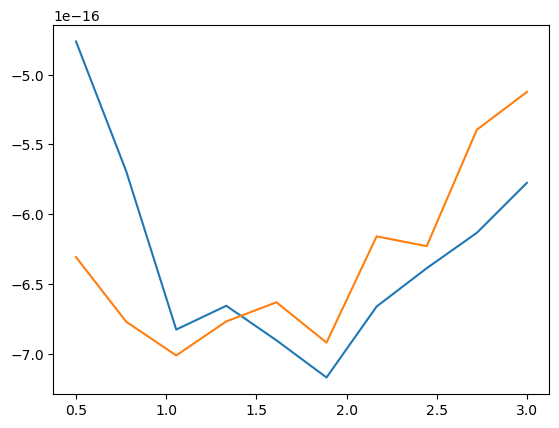

In [508]:
d1 = 0
d2 = 0
d3 = 15
d4 = 14

fig, ax = plt.subplots()
#ax.plot(amp,intercept[:, d1,d2])
ax.plot(amp,intercept[:, d1,d2])
ax.plot(amp,intercept[:, d3,d4])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

Error? Or chaos? This doesn't look very straight in any obvious function. It is possible that there are several subdominate terms here. Even without the derivative term, ... 

Most of them look slightly parabolic, with a minimum value around $1.5$. The greater the derivative, the greater the minimum, while for smaller derivatives, the function is just constant increase.

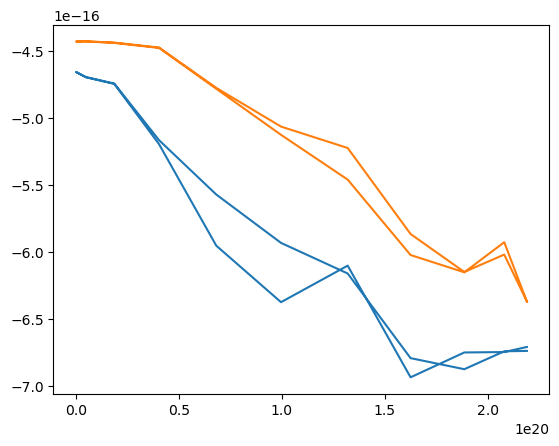

In [309]:
k1 = 2
k2 = 8
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,intercept[k1, :,d1])
ax.plot(dlist**2,intercept[k2, :,d2])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

I could get a line from this

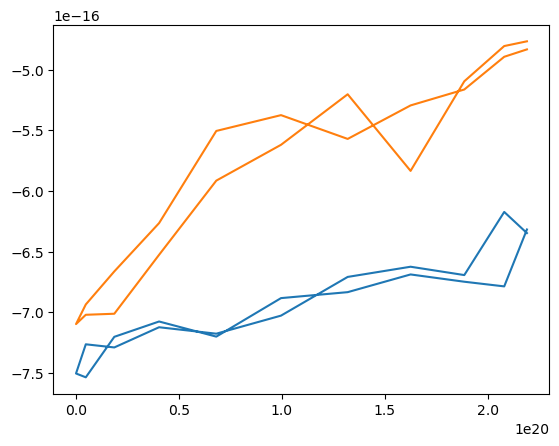

In [510]:
k1 = 2
k2 = 0
d1 = 2
d2 = 19

fig, ax = plt.subplots()
ax.plot(dlist**2,intercept[k1, d1,:])
ax.plot(dlist**2,intercept[k2, d2, :])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

There is a line here as well. Low confidence, however. I am at the edge of my emergent behavior. I don't want to put in other terms due to the chaotic behavior.

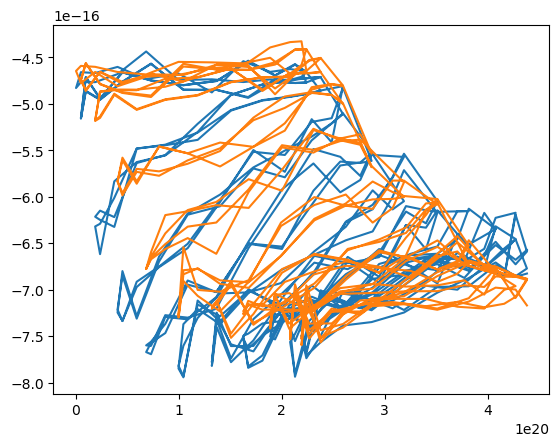

In [318]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,intercept[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,intercept[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
#plt.axline((0,0), (1e-14,0), color='k')
#plt.axline((0,0), (0,1e-14), color='k')
plt.show()

Chaos

Lets start with derivative regression, then $A$ terms. I expect low $R$ numbers and a constant term. However, I am just trying to reduce the error, not eliminate it, so this is not an issue.

In [512]:
np.shape(intercept)

(10, 21, 21)

In [527]:
slopec2d = np.zeros((n_k,2))
interceptc2d = np.zeros((n_k))
r = 1.1    # for finding the minimum r value


for i in range(n_k):
    #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
    X = np.array([np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
    y = intercept[i, :, :].flatten()
    #y = nls

    reg = LinearRegression().fit(X, y)

    slopec2d[i]=reg.coef_
    interceptc2d[i]=reg.intercept_

    r2 = reg.score(X, y)
    #p = max(p, p2)
    #se = max(se, se2)
    r = min(r, r2)

    print(i, slopec2d[i], interceptc2d[i])

print(r)

0 [ 9.82103435e-37 -2.38943357e-37] -6.528616268494345e-16
1 [ 8.09707451e-37 -7.35462941e-37] -6.292365302029352e-16
2 [ 5.74643035e-37 -9.26922028e-37] -5.966657196044782e-16
3 [ 4.42493424e-37 -1.06338038e-36] -5.715154688515448e-16
4 [ 3.19460922e-37 -1.17297170e-36] -5.377494522600508e-16
5 [ 3.14448825e-37 -1.16887107e-36] -5.199178817529648e-16
6 [ 3.33090507e-37 -1.10672789e-36] -5.114674351340891e-16
7 [ 3.05586470e-37 -1.10355487e-36] -4.924680418457111e-16
8 [ 2.92189401e-37 -1.01828255e-36] -4.781154017338162e-16
9 [ 2.84345140e-37 -9.02007912e-37] -4.608897976993317e-16
0.7344602727913105


$0.73$ -- Not bad. Definitely doesn't account for all of the behavior, but we are already dealing with subdominant terms.

In [524]:
slopec3d = np.zeros((3,2))
interceptc3d = np.zeros(3)

i = 0

X = np.array([amp, amp**2]).T
y = slopec2d[:,0]

reg = LinearRegression().fit(X, y)

slopec3d[i]=reg.coef_
interceptc3d[i]=reg.intercept_

r = reg.score(X, y)

print(slopec3d[i], interceptc3d[i], r)

# --------------------------

i = 1

X = np.array([amp, amp**2]).T
y = slopec2d[:,1]

reg = LinearRegression().fit(X, y)

slopec3d[i]=reg.coef_
interceptc3d[i]=reg.intercept_

r = reg.score(X, y)

print(slopec3d[i], interceptc3d[i], r)

# ---------------------------

i = 2

X = np.array([amp, amp**2]).T
y = interceptc2d

reg = LinearRegression().fit(X, y)

slopec3d[i]=reg.coef_
interceptc3d[i]=reg.intercept_

r = reg.score(X, y)

print(slopec3d[i], interceptc3d[i], r)

[-9.50233974e-37  1.99302457e-37] 1.3914817642907674e-36 0.9696780878440856
[-1.49349482e-36  3.70880551e-37] 2.9798884160182696e-37 0.9416467116442603
[ 1.32898596e-16 -1.61244295e-17] -7.180158197309883e-16 0.995269792435964


In [522]:
-9.50233974e-37/t_new**2*eelib.pi**2

-1.3684081910360133e-16

If I want to use these, I need to use all of them. ... 

In [529]:
slopec3d[2]

array([ 1.32898596e-16, -1.61244295e-17])

In [530]:
consts["intercept"]  = interceptc3d[2]
consts["R2"]         = interceptc3d[0]
consts["I2"]         = interceptc3d[1]
consts["A"]          = slopec3d[2,0]
consts["A2"]         = slopec3d[2,1]
consts["AR2"]        = slopec3d[0,0]
consts["AI2"]        = slopec3d[1,0]
consts["A2R2"]       = slopec3d[0,1]
consts["A2I2"]       = slopec3d[1,1]

In [531]:
consts

{'muA2': 3.674472784525875e-08,
 'muA2I': -5.531358292607069e-22,
 'muA2I2': -4.991135273575304e-32,
 'muA2R2': -7.024012560058291e-32,
 'muR2': 2.5523753976091616e-28,
 'muI2': 2.5519928611190297e-28,
 'muI': -1.432582298179841e-21,
 'muR4': 1.5004342865264372e-51,
 'muI4': 1.6838441819811703e-51,
 'muR2I2': 1.0142216449006209e-50,
 't_0': 2.6179257028429826e-10,
 'intercept': -7.180158197309883e-16,
 'R2': 1.3914817642907674e-36,
 'I2': 2.9798884160182696e-37,
 'A': 1.3289859622975093e-16,
 'A2': -1.6124429538341007e-17,
 'AR2': -9.502339744181178e-37,
 'AI2': -1.4934948234704153e-36,
 'A2R2': 1.993024570853259e-37,
 'A2I2': 3.708805505879392e-37}

I count 20 terms of varying importance.

**Quartic Terms**

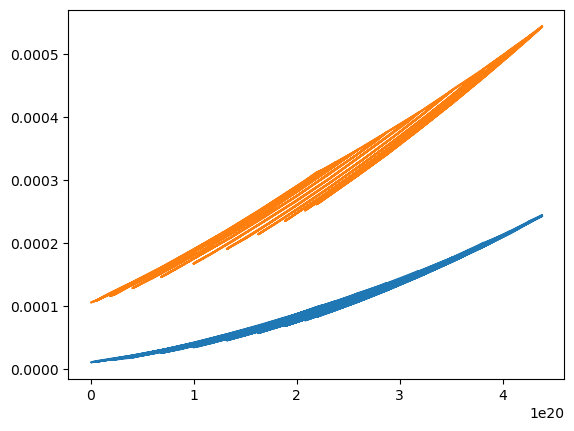

In [319]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,slope_quad[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,slope_quad[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
#plt.axline((0,0), (1e-14,0), color='k')
#plt.axline((0,0), (0,1e-14), color='k')
plt.show()

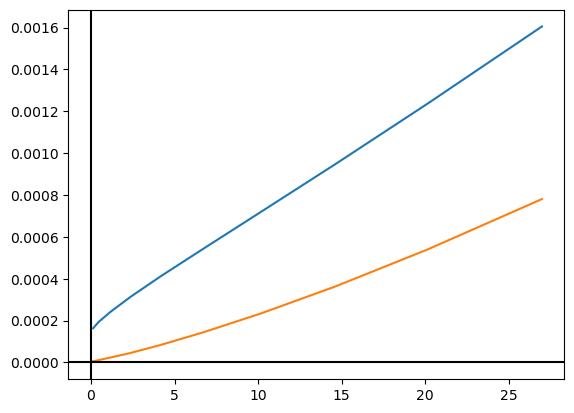

In [322]:
d1 = 0
d2 = 0
d3 = 13
d4 = 12

fig, ax = plt.subplots()
ax.plot(amp**3,slope_quad[:, d1,d2])
ax.plot(amp**3,slope_quad[:, d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

Not quite linear ...

In [532]:
slopeq2a = np.zeros((n_g,n_g,2))
interceptq2a = np.zeros((n_g,n_g))
r = 1.1    # for finding the minimum r value


for j in range(n_g):
    for k in range(n_g):
        #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
        X = np.array([np.power(amp,2), np.power(amp,4)]).T
        y = slope_quad[:, j, k]
        #y = nls

        reg = LinearRegression().fit(X, y)

        slopeq2a[j,k]=reg.coef_
        interceptq2a[j,k]=reg.intercept_

        r2 = reg.score(X, y)
        #p = max(p, p2)
        #se = max(se, se2)
        r = min(r, r2)

        print(j, k, slopeq2a[j,k], interceptq2a[j,k])

print(r)

0 0 [7.93840514e-05 9.22142988e-06] 0.00014323301872262988
0 1 [7.70117626e-05 9.18408434e-06] 0.0001363046686858521
0 2 [7.27672857e-05 9.13563775e-06] 0.00012423027220274127
0 3 [6.72178963e-05 9.06806459e-06] 0.00010824324265843154
0 4 [6.03114885e-05 9.03213538e-06] 9.179396427105792e-05
0 5 [5.30540110e-05 8.99272877e-06] 7.598515906152332e-05
0 6 [4.62068281e-05 8.93848103e-06] 6.180290424959709e-05
0 7 [3.99730436e-05 8.90255666e-06] 5.109379269739817e-05
0 8 [3.56533392e-05 8.83048913e-06] 4.256128983243983e-05
0 9 [3.26621002e-05 8.79214405e-06] 3.81536022816927e-05
0 10 [3.15999514e-05 8.80166783e-06] 3.620434209406859e-05
0 11 [3.25075651e-05 8.82902506e-06] 3.794788660405681e-05
0 12 [3.57459782e-05 8.81862001e-06] 4.261994606173777e-05
0 13 [4.04463413e-05 8.85561682e-06] 5.01072754266121e-05
0 14 [4.62869352e-05 8.91809172e-06] 6.182783937828192e-05
0 15 [5.32157307e-05 8.98187298e-06] 7.574998062966282e-05
0 16 [6.06917219e-05 8.98837373e-06] 9.154650467449037e-05
0 17 [

I see a dependence on the imaginary part of the derivative. Good $R$ value. I will start with these three.

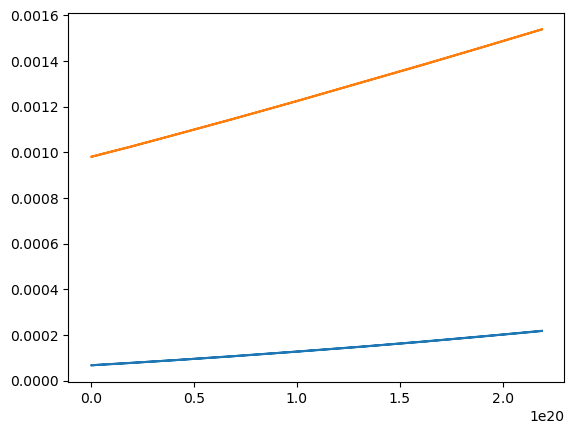

In [323]:
k1 = 2
k2 = 9
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,slope_quad[k1, d1,:])
ax.plot(dlist**2,slope_quad[k2, d2, :])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

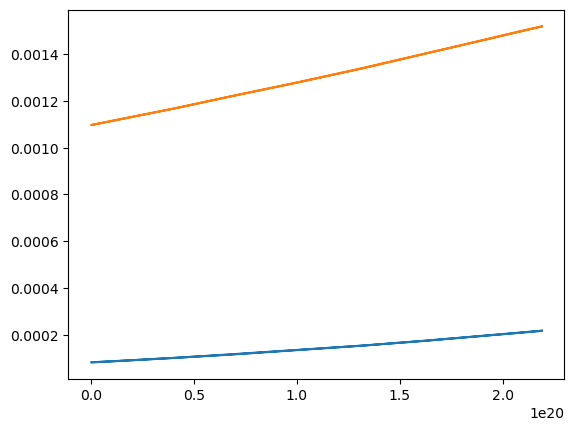

In [324]:
k1 = 2
k2 = 9
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,slope_quad[k1, :,d1])
ax.plot(dlist**2,slope_quad[k2, :,d2])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

$A$ is not quadratic, $\Psi^\prime_0$ rather quadratic. Once I get these terms, it should be enough. 

I should probably do linear regression with many terms to start. If they don't exist, it should be obvious.

In [397]:
slopeq2d = np.zeros((n_k,3))
interceptq2d = np.zeros((n_k))
r = 1.1    # for finding the minimum r value


for i in range(n_k):
    #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
    X = np.array([np.imag(dgrid.flatten()), np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
    y = slope_quad[i, :, :].flatten()
    #y = nls

    reg = LinearRegression().fit(X, y)

    slopeq2d[i]=reg.coef_
    interceptq2d[i]=reg.intercept_

    r2 = reg.score(X, y)
    #p = max(p, p2)
    #se = max(se, se2)
    r = min(r, r2)

    print(i, slopeq2d[i], interceptq2d[i])

print(r)

0 [-2.40163467e-18  3.77081097e-25  3.61634230e-25] -2.616670291584772e-05
1 [-4.27341797e-18  4.53685090e-25  4.16632441e-25] -2.3874342082629837e-05
2 [-7.01580140e-18  5.64733451e-25  4.95477708e-25] -1.6840002037235054e-05
3 [-1.01924617e-17  7.11521850e-25  6.00320318e-25] -1.502717892802347e-06
4 [-9.94457539e-18  8.94062965e-25  7.29312868e-25] 2.771674582259214e-05
5 [-1.42919941e-17  1.11401472e-24  8.85542408e-25] 7.691704573242205e-05
6 [-2.22479050e-17  1.37301976e-24  1.06744217e-24] 0.00015414751863112257
7 [-2.71103659e-17  1.67360064e-24  1.27843960e-24] 0.0002683391158645811
8 [-3.50653290e-17  2.01996546e-24  1.51887682e-24] 0.0004301667978550288
9 [-4.81348450e-17  2.40993892e-24  1.79021628e-24] 0.000652107654152707
0.9407971509728331


In [541]:
np.shape(slopeq2a)

(21, 21, 2)

In [547]:
#slopeq3a = np.zeros((n_g*n_g,3))
#interceptq3a = np.zeros((n_g*n_g))
#r = 1.1    # for finding the minimum r value


X = np.array([np.imag(dgrid.flatten()), np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
y = slopeq2a[:,:,0].flatten()

reg = LinearRegression().fit(X, y)

slopeq3a=reg.coef_
interceptq3a=reg.intercept_

r = reg.score(X, y)

print(slopeq3a, interceptq3a, r)

[-2.50378715e-18  2.14782732e-25  1.53831949e-25] -1.944326178142188e-06 0.9998463466420617


In [548]:
X = np.array([np.imag(dgrid.flatten()), np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
y = slopeq2a[:,:,1].flatten()

reg = LinearRegression().fit(X, y)

slopeq3a2=reg.coef_
interceptq3a2=reg.intercept_

r = reg.score(X, y)

print(slopeq3a2, interceptq3a2, r)

[-2.70653878e-19  1.89798735e-27  1.01670151e-27] 8.574651453484217e-06 0.9816698139343397


In [549]:
X = np.array([np.imag(dgrid.flatten()), np.real(dgrid.flatten())**2, np.imag(dgrid.flatten())**2]).T
y = interceptq2a.flatten()

reg = LinearRegression().fit(X, y)

slopeq3i=reg.coef_
interceptq3i=reg.intercept_

r = reg.score(X, y)

print(slopeq3i, interceptq3i, r)

[-2.90709173e-18  3.23297504e-25  3.23194154e-25] -2.5595832127127215e-05 0.9248324595553732


The $A^2$ has a worse fit, and the $A^0$ term has an even worse fit. They are still good, however, and the error should not be an issue due to our dealing with sub-dominant terms. 12 more correction terms. 

In [550]:
consts["mu2"]     = interceptq3i
consts["mu2I"]    = slopeq3i[0]
consts["mu2R2"]   = slopeq3i[1]
consts["mu2I2"]   = slopeq3i[2]
consts["mu2A"]    = interceptq3a
consts["mu2AI"]   = slopeq3a[0]
consts["mu2AR2"]  = slopeq3a[1]
consts["mu2AI2"]  = slopeq3a[2]
consts["mu2A2"]   = interceptq3a2
consts["mu2A2I"]  = slopeq3a2[0]
consts["mu2A2R2"] = slopeq3a2[1]
consts["mu2A2I2"] = slopeq3a2[2]

In [551]:
consts

{'muA2': 3.674472784525875e-08,
 'muA2I': -5.531358292607069e-22,
 'muA2I2': -4.991135273575304e-32,
 'muA2R2': -7.024012560058291e-32,
 'muR2': 2.5523753976091616e-28,
 'muI2': 2.5519928611190297e-28,
 'muI': -1.432582298179841e-21,
 'muR4': 1.5004342865264372e-51,
 'muI4': 1.6838441819811703e-51,
 'muR2I2': 1.0142216449006209e-50,
 't_0': 2.6179257028429826e-10,
 'intercept': -7.180158197309883e-16,
 'R2': 1.3914817642907674e-36,
 'I2': 2.9798884160182696e-37,
 'A': 1.3289859622975093e-16,
 'A2': -1.6124429538341007e-17,
 'AR2': -9.502339744181178e-37,
 'AI2': -1.4934948234704153e-36,
 'A2R2': 1.993024570853259e-37,
 'A2I2': 3.708805505879392e-37,
 'mu2': -2.5595832127127215e-05,
 'mu2I': -2.9070917287770292e-18,
 'mu2R2': 3.232975035288853e-25,
 'mu2I2': 3.2319415368919054e-25,
 'mu2A': -1.944326178142188e-06,
 'mu2AI': -2.503787152828287e-18,
 'mu2AR2': 2.147827317198672e-25,
 'mu2AI2': 1.538319488984782e-25,
 'mu2A2': 8.574651453484217e-06,
 'mu2A2I': -2.7065387775566594e-19,
 'mu

Next step: 

* checking (compare to known results)
* check compared to a new set of data with the same $k$ and $M$, but new $A_0$, $\mu$, and $\Psi^\prime_0$
* find $k$ and $M$ dependencies

My guess is that the sub-dominant terms are dependent on powers of $\frac{M}{k}$. I will need to check for other $M$ and $k$ dependencies besides those which I expect. With 32 terms, it is not the most pleasent, but I now know what I am looking for, have the code, and it runs at a reasonable rate. I just need to wait for a bigger grid ... 

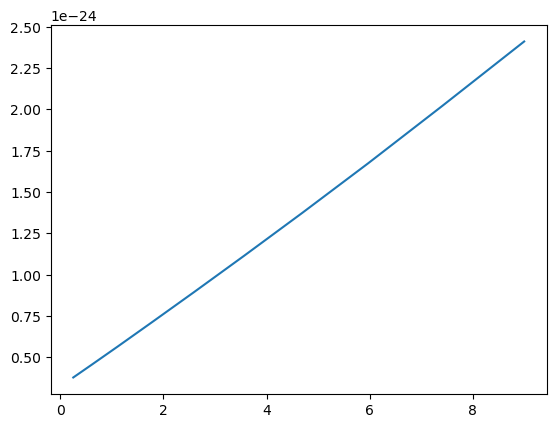

In [404]:
fig, ax = plt.subplots()
ax.plot(amp**2,slopeq2a[:,1])

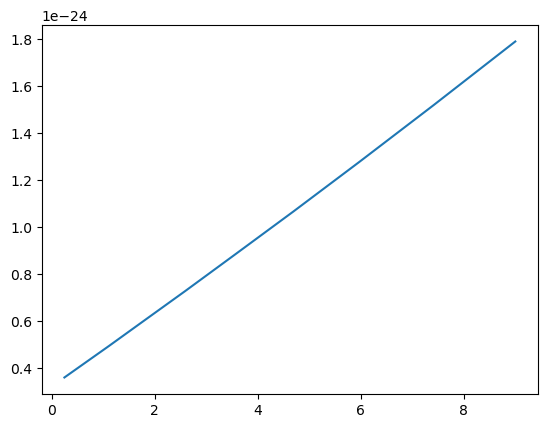

In [405]:
fig, ax = plt.subplots()
ax.plot(amp**2,slopeq2a[:,2])

# Big Regression

This didn't work very well. I think there are instabilities in the matrix. 

In [440]:
X = np.array([np.log(npaf[:,1]), npaf[:,2]**2, npaf[:,3]**2,               # intercept terms
     npaf[:,0]*npaf[:,1]**2, npaf[:,0]*npaf[:,1]*npaf[:,3],                # linear mu with A_0
     npaf[:,0]*npaf[:,2]**2, npaf[:,0]*npaf[:,3]**2, npaf[:,0]*npaf[:,3],  # linear mu without A_0
     npaf[:,0]**2*npaf[:,1]**2, npaf[:,0]**2*npaf[:,1]**4,                 # pure amp terms 
     npaf[:,0]**2*npaf[:,3], npaf[:,0]**2*npaf[:,2]**2, npaf[:,0]**2*npaf[:,3]**2,   # pure deriv terms
     npaf[:,0]**2*npaf[:,3]*npaf[:,1]**2, npaf[:,0]**2*npaf[:,3]*npaf[:,1]**4,
     npaf[:,0]**2*npaf[:,2]**2*npaf[:,1]**2, npaf[:,0]**2*npaf[:,2]**2*npaf[:,1]**2]).T # high order terms         
y = npaf[:,5]
np.shape(X)

(88200, 17)

In [441]:
reg = LinearRegression().fit(X, y)

slope_full=reg.coef_
intercept_full=reg.intercept_

r = reg.score(X, y)

print(slope_full, intercept_full)

print(r)

[-2.20120826e-85  1.49508555e-55  1.37767351e-55 -8.56440029e-62
 -4.23083923e-62 -2.30329559e-52 -2.04034410e-52 -9.63858668e-73
 -4.46415424e-87 -1.06960648e-84  2.61795069e-70  5.78716207e-50
  4.62406665e-50  9.51564115e-68  1.41899799e-64  2.41294983e-54
  2.41295008e-54] -5.5618018107841745e-15
0.2508300272853331


In [ ]:
X = np.array([ npaf[:,2]**2, npaf[:,3]**2,
                 # linear mu with A_0
     npaf[:,0]*npaf[:,2]**2,  npaf[:,0]*npaf[:,3]**2,   # linear mu without A_0
                       # pure amp terms 
     npaf[:,0]**2*npaf[:,2]**2,   # pure deriv terms
     npaf[:,0]**2*npaf[:,2]**2*npaf[:,1]**2]).T # high order terms         
y = npaf[:,5]

reg = LinearRegression().fit(X, y)

slope_full=reg.coef_
intercept_full=reg.intercept_

r = reg.score(X, y)

print(slope_full, intercept_full)

print(r)

In [439]:
X = np.array([ npaf[:,2]**2, npaf[:,3]**2,
                 # linear mu with A_0
     npaf[:,0]*npaf[:,2]**2,  npaf[:,0]*npaf[:,3]**2,   # linear mu without A_0
                       # pure amp terms 
     npaf[:,0]**2*npaf[:,2]**2,   # pure deriv terms
     npaf[:,0]**2*npaf[:,2]**2*npaf[:,1]**2]).T # high order terms         
y = npaf[:,5]

reg = LinearRegression().fit(X, y)

slope_full=reg.coef_
intercept_full=reg.intercept_

r = reg.score(X, y)

print(slope_full, intercept_full)

print(r)

[ 1.73476166e-55  9.06374764e-56 -2.97828414e-52 -7.13047636e-53
  8.13870305e-50  4.82589991e-54] -5.561801810779801e-15
0.23676024662738193


# Recalculation of Model Error

Here are our parameters.

In [552]:
consts

{'muA2': 3.674472784525875e-08,
 'muA2I': -5.531358292607069e-22,
 'muA2I2': -4.991135273575304e-32,
 'muA2R2': -7.024012560058291e-32,
 'muR2': 2.5523753976091616e-28,
 'muI2': 2.5519928611190297e-28,
 'muI': -1.432582298179841e-21,
 'muR4': 1.5004342865264372e-51,
 'muI4': 1.6838441819811703e-51,
 'muR2I2': 1.0142216449006209e-50,
 't_0': 2.6179257028429826e-10,
 'intercept': -7.180158197309883e-16,
 'R2': 1.3914817642907674e-36,
 'I2': 2.9798884160182696e-37,
 'A': 1.3289859622975093e-16,
 'A2': -1.6124429538341007e-17,
 'AR2': -9.502339744181178e-37,
 'AI2': -1.4934948234704153e-36,
 'A2R2': 1.993024570853259e-37,
 'A2I2': 3.708805505879392e-37,
 'mu2': -2.5595832127127215e-05,
 'mu2I': -2.9070917287770292e-18,
 'mu2R2': 3.232975035288853e-25,
 'mu2I2': 3.2319415368919054e-25,
 'mu2A': -1.944326178142188e-06,
 'mu2AI': -2.503787152828287e-18,
 'mu2AR2': 2.147827317198672e-25,
 'mu2AI2': 1.538319488984782e-25,
 'mu2A2': 8.574651453484217e-06,
 'mu2A2I': -2.7065387775566594e-19,
 'mu

In [640]:
#f_dt_A2 = np.zeros((n_m, n_k, n_g, n_g))
g_fun = np.zeros((n_m, n_k, n_g, n_g))
for nn in range(n_m): 
    for ii in range(n_k):
        for jj in range(n_g):
            for kk in range(n_g):
                # mu = 0 period
                g_fun[nn,ii,jj,kk] = fot[nn,ii,jj,kk] - t_new 
                # A_0 quadratic term
                #g_fun[nn,ii,jj,kk] = g_fun[nn,ii,jj,kk] / nls[ii]
                g_fun[nn,ii,jj,kk] -= slope_A*amp[ii]**2 *nls[nn]
                # linear and quadratic terms for psi '
                g_fun[nn,ii,jj,kk] -= slope_0_d*np.abs(dgrid[jj,kk])**2 *nls[nn] - np.sqrt(2)*slope_0_d*np.imag(dgrid[jj,kk])*gridl.l_calc.M * nls[nn]
                # quartic psi ' terms
                g_fun[nn,ii,jj,kk] -= nls[nn]*np.matmul(slope_4_d,np.array([np.real(dgrid[i,j])**4, 
                                                                    np.real(dgrid[i,j])**2*np.imag(dgrid[i,j])**2, 
                                                                    np.imag(dgrid[i,j])**4]).T)

In [ ]:
t_pred = np.zeros((n_m, n_k, n_g, n_g))

for nn in range(n_m): 
    for ii in range(n_k):
        for jj in range(n_g):
            for kk in range(n_g):
                # constant terms -- t_0 and intercept (error)
                t_pred[nn,ii,jj,kk] = consts['t_0'] + consts['intercept']
                # terms independent of mu (error)
                t_pred[nn,ii,jj,kk] += np.real(dgrid[jj,kk])**2 * consts['R2'] + np.imag(dgrid[jj,kk])**2 * consts['I2']
                #t_pred[nn,ii,jj,kk] += amp[ii] * (#consts['A'] + 
                #                                  np.real(dgrid[jj,kk])**2 * consts['AR2'] 
                #                                  + np.imag(dgrid[jj,kk])**2 * consts['AI2'])
                t_pred[nn,ii,jj,kk] += amp[ii]**2 * (#consts['A2'] + 
                                                     np.real(dgrid[jj,kk])**2 * consts['A2R2'] 
                                                     + np.imag(dgrid[jj,kk])**2 * consts['A2I2'])
                # mu linear terms
                t_pred[nn,ii,jj,kk] += nls[nn]*(np.imag(dgrid[jj,kk]) * consts['muI'] + np.real(dgrid[jj,kk])**2 * slope_0_d
                                                + np.imag(dgrid[jj,kk])**2 * slope_0_d + np.imag(dgrid[jj,kk])**4 * consts['muI4']
                                                + np.real(dgrid[jj,kk])**4 * consts['muR4'] 
                                                + np.real(dgrid[jj,kk])**2 *np.imag(dgrid[jj,kk])**2 * consts['muR2I2'])
                t_pred[nn,ii,jj,kk] += nls[nn]*amp[ii]**2 * (slope_A) # + np.imag(dgrid[jj,kk]) * consts['muA2I'] 
                                        #+ np.real(dgrid[jj,kk])**2 * consts['muA2R2'] + np.imag(dgrid[jj,kk])**2 * consts['muA2I2'])

                # mu quadradic terms
                t_pred[nn,ii,jj,kk] += nls[nn]**2 *(consts['mu2'] + np.imag(dgrid[jj,kk]) * consts['mu2I'] 
                                        + np.real(dgrid[jj,kk])**2 * consts['mu2R2'] + np.imag(dgrid[jj,kk])**2 * consts['mu2I2'])
                t_pred[nn,ii,jj,kk] += nls[nn]**2*amp[ii] *(consts['mu2A'] + np.imag(dgrid[jj,kk]) * consts['mu2AI'] 
                                        + np.real(dgrid[jj,kk])**2 * consts['mu2AR2'] + np.imag(dgrid[jj,kk])**2 * consts['mu2AI2'])
                t_pred[nn,ii,jj,kk] += nls[nn]**2*amp[ii]**2 *(consts['mu2A2'] + np.imag(dgrid[jj,kk]) * consts['mu2A2I'] 
                                        + np.real(dgrid[jj,kk])**2 * consts['mu2A2R2'] + np.imag(dgrid[jj,kk])**2 * consts['mu2A2I2'])

In [634]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.3779742305392494e-14, -3.0497782371535795e-14)

In [637]:
np.max(fot-t_new), np.min(fot-t_new)

(4.583373595434384e-12, -6.453122620035401e-16)

In [630]:
1.3779742305392494e-14--3.0497782371535795e-14

4.427752467692829e-14

In [632]:
2.2075157139558506e-14+2.6685114157973038e-14

4.8760271297531544e-14

In [641]:
np.max(g_fun), np.min(g_fun)

(6.367791568660633e-14, -2.9850828899796044e-14)

In [ ]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k* n_m * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = g_fun[imu, ia, idr, idi]

So, the new model is not so good. I want to mix old model and new model parameters in order to get the best results. I think I need to split constant, linear, and quadratic $\mu$ terms at the beginning. Then, for each, constant, linear, and quadratic $A$ terms. After that, for each constant, imaginary linear, uncoupled quadratic, and quartic terms for $\Psi^\prime_0$. If the new model works better, we can then try to add in $k$ and $M$ dependence. The dominant terms were quite well removed. 

# New Attempt

**Start with splitting $\mu$**

In [720]:
slope = np.zeros((n_k,n_g,n_g,2))
intercept = np.zeros((n_k,n_g,n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
            X = np.array([nls, np.power(nls,2)]).T
            y = fot[:, i, j, k]-t_new
            #y = nls

            reg = LinearRegression().fit(X, y)

            slope[i,j,k]=reg.coef_
            intercept[i,j,k]=reg.intercept_

            r2 = reg.score(X, y)
            #p = max(p, p2)
            #se = max(se, se2)
            r = min(r, r2)

            #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999998227732203


This is the best yet, I think, for $R$. It should be within the desired margin of error. Adding a $\mu^3$ term didn't help.

In [721]:
print(np.min(slope[:,:,:,0])*1e-6, np.max(slope[:,:,:,0])*1e-6)
print(np.min(slope[:,:,:,1])*1e-12, np.max(slope[:,:,:,1])*1e-12)
print(np.min(intercept), np.max(intercept))

9.185612145208398e-15 4.423186746019675e-13
7.028224790627272e-19 1.605811185640647e-15
-7.943749327765334e-16 -4.168267610940774e-16


**$A$ terms for $\mu$**

Rescaling of $A$ should be equivalent to rescaling $\mu$ ... Perhaps I should just assume this. 
$A$ terms independent of $\mu$ seem not to exist. Lets use what I know. Note that $\Psi^\prime_0$ has a factor of $A$.

In [824]:
slope_mA = np.zeros((2,n_g,n_g,2))
intercept_mA = np.zeros((2,n_g,n_g))
r = 1.1    # for finding the minimum r value

i = 0

for j in range(n_g):
    for k in range(n_g):
        X = np.array([np.power(amp,1), np.power(amp,2)]).T
        y = slope[:, j, k, 0]

        reg = LinearRegression().fit(X, y)

        slope_mA[i,j,k]=reg.coef_
        intercept_mA[i,j,k]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999999737377857


In [825]:
print(np.min(slope_mA[0,:,:,0])*1e-6, np.max(slope_mA[0,:,:,0])*1e-6)
print(np.min(slope_mA[0,:,:,1])*1e-6, np.max(slope_mA[0,:,:,1])*1e-6)
print(np.min(intercept_mA[0])*1e-6, np.max(intercept_mA[0])*1e-6)

2.6055003314970693e-17 1.664829455765285e-16
3.6678538842787266e-14 3.673173788480454e-14
-2.4268981772165768e-17 1.1172860516686399e-13


The main terms are $\mu A^2$ and $\mu$ with $\mu^2 A$ being just a correction, as expected. (Almost) all corrections are positive. Error is small.

$A^3$ corrections around $10^{-17}$. $A^4$ around $5*10^{-18}$. This may be a minor issue if A becomes large. Perhaps analyzing large $A$ cases will give a better correction here, if there is an issue.

**$A$ terms for $\mu^2$**

In [840]:
r = 1.1    # for finding the minimum r value
i = 1

for j in range(n_g):
    for k in range(n_g):
        X = np.array([ np.power(amp, 2),  np.power(amp,4)]).T
        y = slope[:, j, k, 1]

        reg = LinearRegression().fit(X, y)

        slope_mA[i,j,k]=reg.coef_
        intercept_mA[i,j,k]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999841722100655


In [833]:
print(np.min(slope_mA[1,:,:,0])*1e-12, np.max(slope_mA[1,:,:,0])*1e-12)
print(np.min(slope_mA[1,:,:,1])*1e-12, np.max(slope_mA[1,:,:,1])*1e-12)
print(np.min(intercept_mA[1])*1e-12, np.max(intercept_mA[1])*1e-12)

-1.4457554136558708e-18 7.938405139294821e-17
8.575481152578407e-18 9.251166669332015e-18
8.873939370168573e-19 1.437104783751801e-16


Corrections from $\mu^2 A$ are negative. All corrections within the $10^{-16}$ range, so the $R$ value is unlikely to be an issue. The $A^4$ term helps with this issue, but is likely unneeded. 

**$A$ terms independent of $\mu$**


In [717]:
r = 1.1    # for finding the minimum r value
i = 2

for j in range(n_g):
    for k in range(n_g):
        X = np.array([np.power(amp,2), np.power(amp,-1)]).T
        y = intercept[:, j, k]

        reg = LinearRegression().fit(X, y)

        slope_mA[i,j,k, 0:2]=reg.coef_
        intercept_mA[i,j,k]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.10223338181116393


I would like to just assume independence here. Log helps a little. I will leave this for later.

**$\Psi^\prime_0$ Linear Terms**

In [843]:
slope_mF = np.zeros((2,3,6))
intercept_mF = np.zeros((2,3))
r = 1.1    # for finding the minimum r value

nn = 0
mm = 0

#X = np.array([np.power(amp,1), np.power(amp,2), np.power(amp,-1), np.power(amp,-2)]).T

dg_r = np.real(dgrid).flatten() * t_new / eelib.pi
dg_i = np.imag(dgrid).flatten() * t_new / eelib.pi

X = np.array([dg_i]).T
y = slope_mA[nn, :, :, mm].flatten()

reg = LinearRegression().fit(X, y)

slope_mF[nn,mm,0]=reg.coef_[0]
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-6, intercept_mF[nn,mm]*1.e-6)

print(r)

print(np.average(y)*1e-6)

[-2.45035985e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00] 8.524683685031718e-17
0.487823131280714
8.524683685031718e-17


In [844]:
consts2 = {}
consts2['ma']=np.average(y)

In [845]:

r = 1.1    # for finding the minimum r value

nn = 0
mm = 1

#X = np.array([np.power(amp,1), np.power(amp,2)]).T

dg_r = np.real(dgrid).flatten() * t_new / eelib.pi
dg_i = np.imag(dgrid).flatten() * t_new / eelib.pi

X = np.array([dg_i**2, dg_r**2]).T
y = slope_mA[nn, :, :, mm].flatten()

reg = LinearRegression().fit(X, y)

slope_mF[nn,mm,0:2]=reg.coef_
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-6, intercept_mF[nn,mm]*1.e-6)

print(r)

print(np.average(y)*1e-6)

[-1.17969263e-17 -1.90912407e-17  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00] 3.673157260723046e-14
0.9474620383354295
3.670825164904433e-14


In [846]:
consts2['ma2']=np.average(y)

In [847]:
consts2

{'ma': 8.524683685031718e-11, 'ma2': 3.6708251649044334e-08}

In [861]:
r = 1.1    # for finding the minimum r value

nn = 1
mm = 0

X = np.array([dg_i**4, dg_r**4, dg_r**2* dg_i**2]).T
y = slope_mA[nn, :, :, mm].flatten()

reg = LinearRegression().fit(X, y)

slope_mF[nn,mm,0:3]=reg.coef_
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-12, intercept_mF[nn,mm]*1.e-12)

print(r)

print(np.average(slope_mA[nn, :, :, mm].flatten())*1e-12)

[1.04293848e-17 1.58594873e-17 6.99809399e-18 0.00000000e+00
 0.00000000e+00 0.00000000e+00] 1.1541085420477739e-17
0.9541661753752614
3.8134223110126934e-17


In [862]:
slope_mF[1,0]

array([1.04293848e-05, 1.58594873e-05, 6.99809399e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [863]:
consts2['m2a2di4']=np.average(slope_mF[1, 0, 0].flatten())
consts2['m2a2dr4']=np.average(slope_mF[1, 0, 1].flatten())
consts2['m2a2di2dr2']=np.average(slope_mF[1, 0, 2].flatten())
consts2['m2a2']=np.average(intercept_mF[1,0].flatten())

In [849]:
r = 1.1    # for finding the minimum r value

nn = 1
mm = 1

X = np.array([dg_i, dg_i**2, dg_r**2, dg_i**4, dg_r**4, dg_i**2*dg_r**2]).T
y = slope_mA[nn, :, :, mm].flatten()

reg = LinearRegression().fit(X, y)

slope_mF[nn,mm,0:6]=reg.coef_
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-12, intercept_mF[nn,mm]*1.e-12)

print(r)

print(np.average(slope_mA[nn, :, :, mm].flatten())*1e-12)

[-3.24793111e-21  1.33472373e-19  2.59059141e-19  2.51048971e-21
  3.38072300e-21  1.20764094e-20] 8.583242464500935e-18
0.9821278592225038
8.89155825918533e-18


In [850]:
consts2['m2a4']=np.average(slope_mA[1, :, :, 1].flatten())

In [754]:
np.min(y)

7.60341457608064e-12

In [851]:
r = 1.1    # for finding the minimum r value

nn = 0
mm = 2

#X = np.array([np.power(amp,1), np.power(amp,2), np.power(amp,-1), np.power(amp,-2)]).T

X = np.array([dg_i**2, dg_r**2]).T
y = intercept_mA[nn, :, :].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mF[nn,mm,0:2]=reg.coef_
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-6, intercept_mF[nn,mm]*1.e-6)

print(r)

[3.67262958e-14 3.67201328e-14 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00] 0.0
0.9999998105093848


In [853]:
consts2['mdi2']=slope_mF[0,2,0]
consts2['mdr2']=slope_mF[0,2,1]

In [854]:
r = 1.1    # for finding the minimum r value

nn = 1
mm = 2

#X = np.array([np.power(amp,1), np.power(amp,2), np.power(amp,-1), np.power(amp,-2)]).T

X = np.array([dg_i**4, dg_r**4, dg_i**2*dg_r**2]).T
y = intercept_mA[nn, :, :].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mF[nn,mm,0:3]=reg.coef_
intercept_mF[nn,mm]=reg.intercept_

r = reg.score(X, y)

print(slope_mF[nn,mm]*1.e-12, intercept_mF[nn,mm]*1.e-12)

print(r)

[1.57673221e-17 1.57730264e-17 3.04261943e-17 0.00000000e+00
 0.00000000e+00 0.00000000e+00] 0.0
0.999789912119918


In [855]:
consts2['m2di4'] = slope_mF[1,2,0]
consts2['m2dr4'] = slope_mF[1,2,1]

In [747]:
np.max(dg_r)

1.23333685649208

In [856]:
nn = 0
mm = 1

der_col = []
inter_col = []

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            der_col.append(dgrid[j,k] * t_new / eelib.pi)
            inter_col.append(intercept[i,j,k])

X = np.array([np.real(der_col)**2, np.imag(der_col) **2]).T
y = np.array(inter_col)

reg = LinearRegression().fit(X, y)

slope_ii=reg.coef_
intercept_ii=reg.intercept_

r = reg.score(X, y)

print(slope_ii, intercept_ii)

print(r)

print(np.average(inter_col))

[ 6.70796816e-17 -1.35901674e-16] -5.450887355934651e-16
0.6612842614622403
-5.970502133169344e-16


In [857]:
consts2['intercept'] = intercept_ii
consts2['dr2'] = slope_ii[0]
consts2['di2']=slope_ii[1]

In [864]:
consts2

{'ma': 8.524683685031718e-11,
 'ma2': 3.6708251649044334e-08,
 'm2a2di4': 1.0429384849338137e-05,
 'm2a2dr4': 1.5859487255799146e-05,
 'm2a2di2dr2': 6.998093988956121e-06,
 'm2a2': 1.1541085420477739e-05,
 'm2a4': 8.89155825918533e-06,
 'mdi2': 3.672629582408101e-08,
 'mdr2': 3.6720132831118564e-08,
 'm2di4': 1.5767322103359433e-05,
 'm2dr4': 1.5773026377959536e-05,
 'intercept': -5.450887355934651e-16,
 'dr2': 6.70796815755615e-17,
 'di2': -1.3590167364639887e-16}

In [865]:
slope_A

3.772390428468754e-08

Lets try this model, then the $A_0$ removal variant. I still have many terms sensitive to $A_0$ despite the fact that they should not be. I also have a shift in the period. I should see what happens if I force the intercept to zero. I am likely already into my error. I also want to see if adding the intercept term to the period reduces the error. I can also run the code again with new values, and see how that changes my results.

# Model Testing Attempt 2

In [875]:
dgrid_n = dgrid * t_new / eelib.pi

In [882]:
t_pred = np.zeros((n_m, n_k, n_g, n_g))

for nn in range(n_m): 
    for ii in range(n_k):
        for jj in range(n_g):
            for kk in range(n_g):
                # constant terms -- t_0 and intercept (error)
                t_pred[nn,ii,jj,kk] = t_new + consts2['intercept']
                # terms independent of mu (error)
                t_pred[nn,ii,jj,kk] += np.real(dgrid_n[jj,kk])**2 * consts2['dr2'] + np.imag(dgrid_n[jj,kk])**2 * consts2['di2']

                # mu linear terms
                t_pred[nn,ii,jj,kk] += nls[nn]*(np.real(dgrid_n[jj,kk])**2 * consts2['mdr2']
                                              + np.imag(dgrid_n[jj,kk])**2 * consts2['mdi2'])
                t_pred[nn,ii,jj,kk] += nls[nn]*amp[ii]**2 * consts2['ma2']
                t_pred[nn,ii,jj,kk] += nls[nn]*amp[ii] * consts2['ma']

                # mu quadradic terms
                t_pred[nn,ii,jj,kk] += nls[nn]**2 *(np.imag(dgrid_n[jj,kk])**4 * consts2['m2di4'] 
                                                  + np.real(dgrid_n[jj,kk])**4 * consts2['m2dr4'])
                
                t_pred[nn,ii,jj,kk] += nls[nn]**2*amp[ii]**2 *(np.imag(dgrid_n[jj,kk])**4 * consts2['m2a2di4'] 
                                                             + np.real(dgrid_n[jj,kk])**4 * consts2['m2a2dr4'] 
                                        + np.imag(dgrid_n[jj,kk])**2 * np.real(dgrid_n[jj,kk])**2 * consts2['m2a2di2dr2'])
                
                t_pred[nn,ii,jj,kk] += nls[nn]**2*amp[ii]**2 * (consts2['m2a2'] + amp[ii]**2 * consts2['m2a4'])

In [883]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.0176174674624867e-14, -1.3406261069158389e-14)

In [878]:
np.max(g_fun), np.min(g_fun)

(6.367791568660633e-14, -2.9850828899796044e-14)

In [879]:
np.max(fot-t_new), np.min(fot-t_new)

(4.583373595434384e-12, -6.453122620035401e-16)

Definately the best model so far. I want to now look at the triangle plots, then test the model to see if it is good enough. I also have another idea for getting a model, and I can try removing $A_0$ as well. I originally includer $A_0$ based on a hypothesis of $A_{max}$ dependence, which seems false.

In [884]:
new_g = fot-t_pred

In [885]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k* n_m * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = new_g[imu, ia, idr, idi]

88200
True


In [886]:
dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "D T fast"])

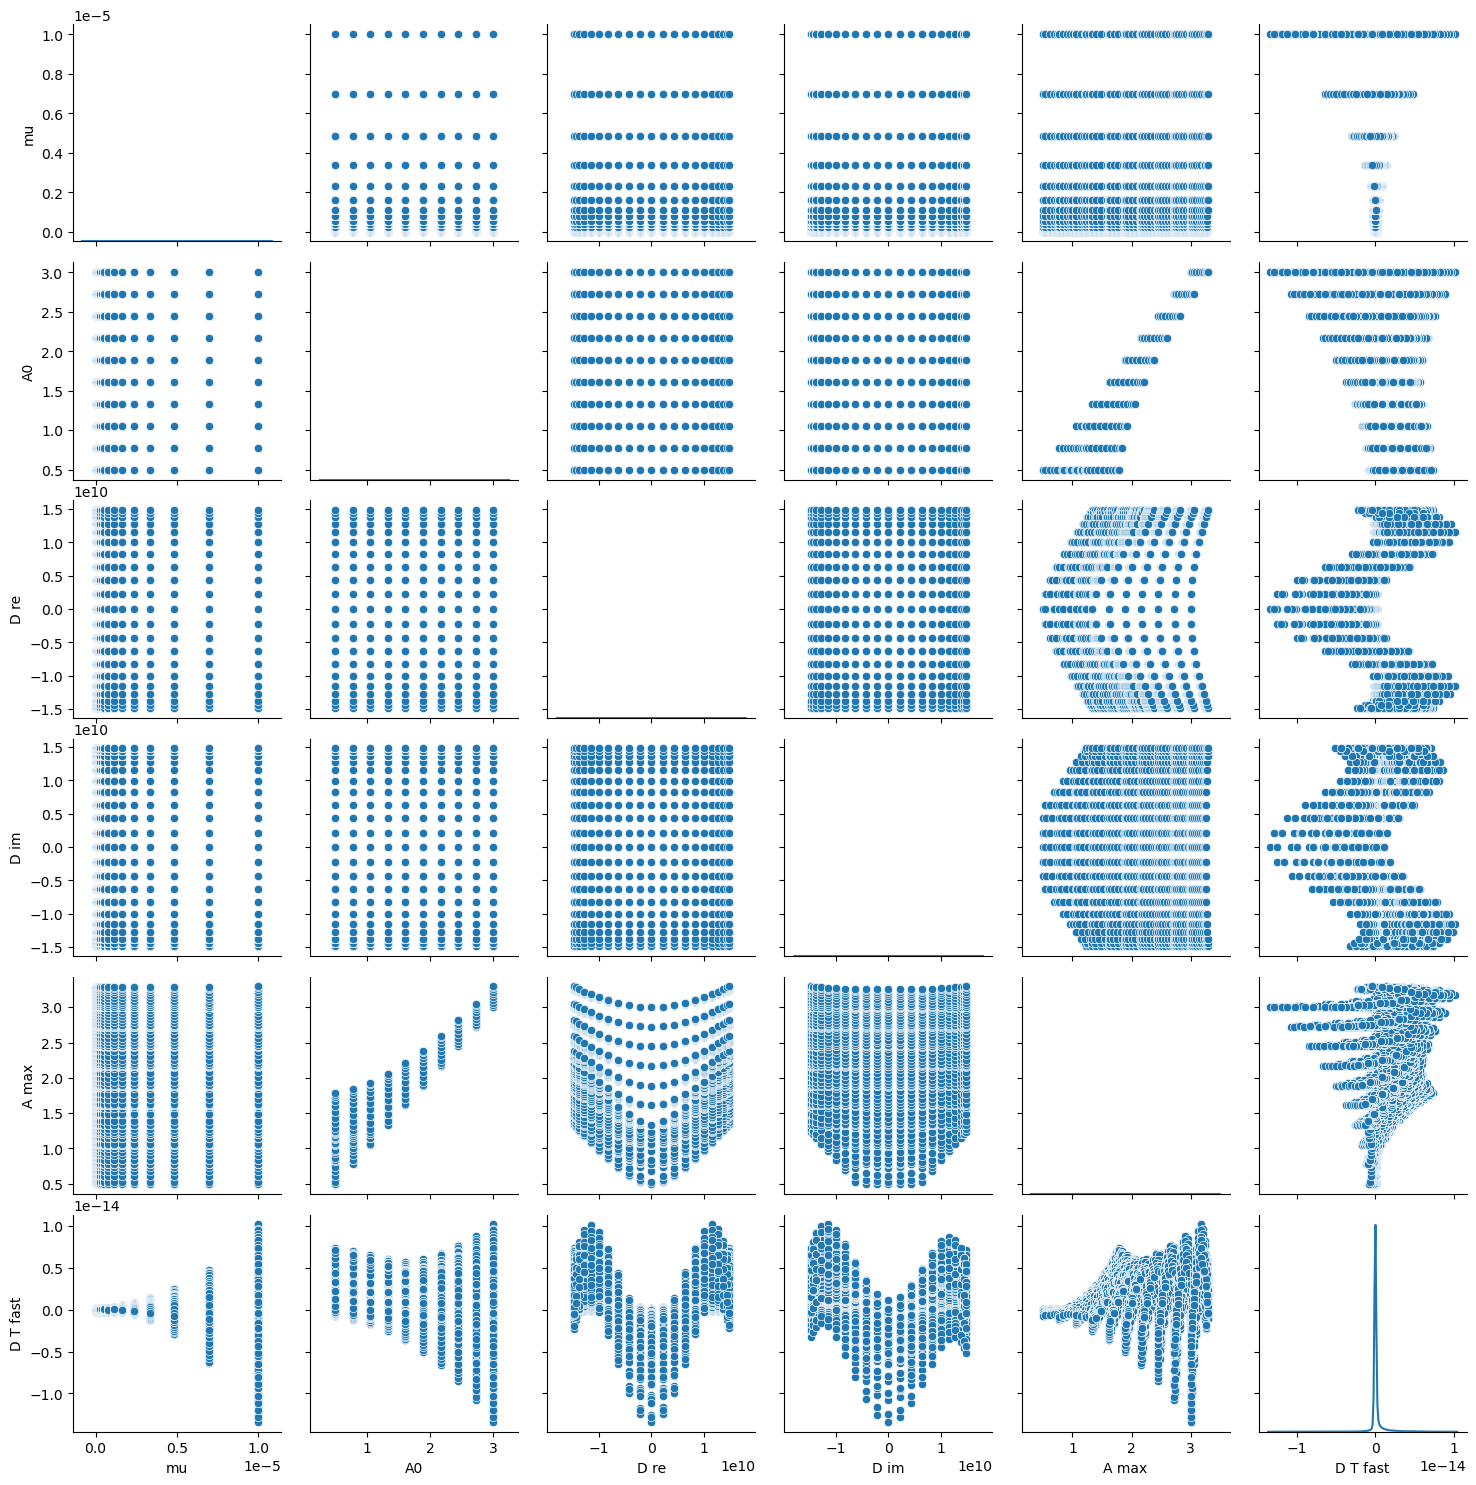

In [887]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

Model is strongly peaked around my expected value. $\mu$ error grows with $\mu$ as expected. There is a term linear in $\Im(\Psi^\prime)$ and quartic $\Psi^\prime$ terms. $\mu$ terms here are quadratic. $A_0$ terms are linear or quadratic.

In [888]:
#t_0 = eelib.pi/eelib.kFAu
#npaf[:,-1]= npaf[:,-1]-t_new
#npaf[:,-1]= npaf[:,-1] / npaf[:,0]
npaf[:,0]=np.power(npaf[:,0], 2)
#npaf[:,1]=np.power(npaf[:,1],2)
npaf[:,2]=np.power(npaf[:,2],4)
npaf[:,3]=np.power(npaf[:,3],4)

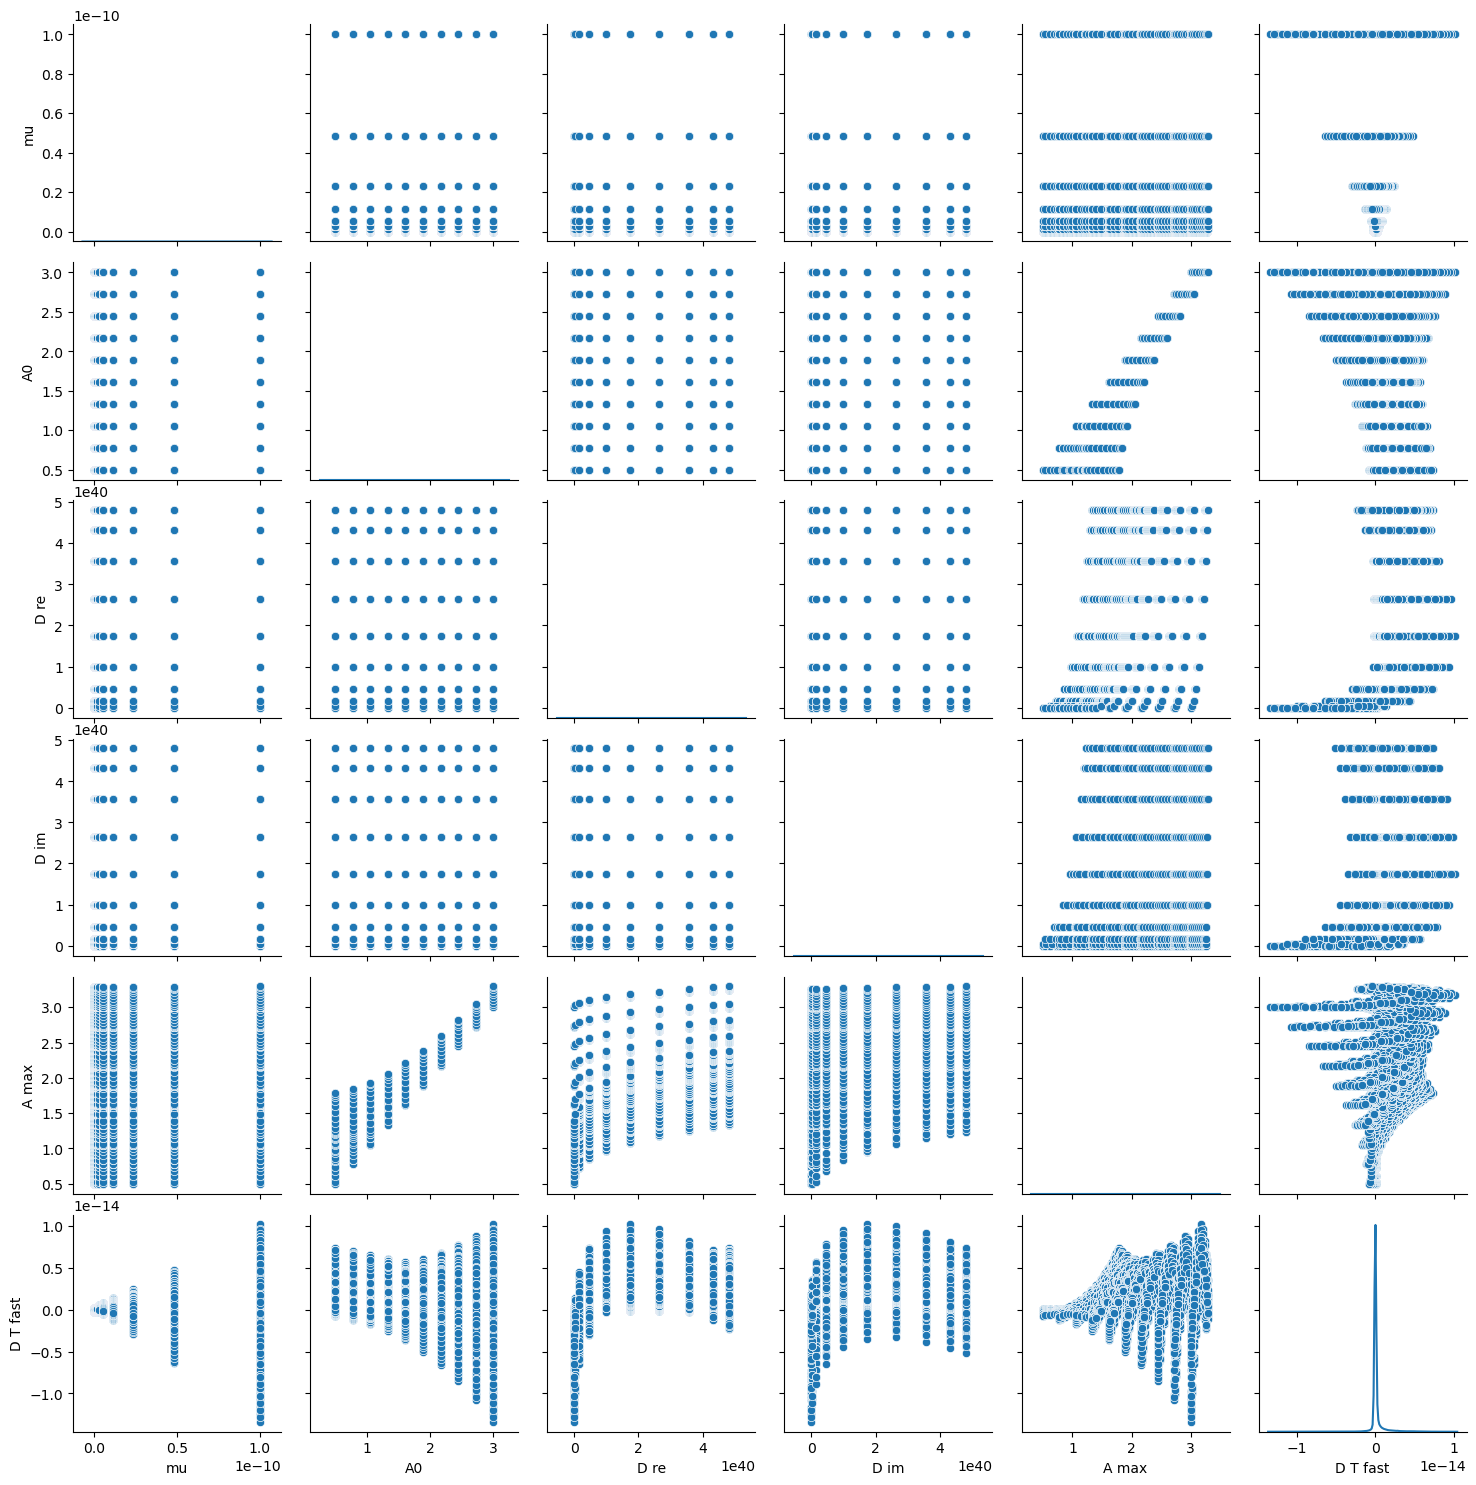

In [889]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

Error is definitely quadratic in $\mu$. It is likely unimportant for small $\mu$, and I am already close enough to my expected value. I would like to try now to redo the model without $A_0$, but with $k$ and $M$. I think it is time that I can clear my memory and run the code again. 

# Removing $A_0$